<a href="https://colab.research.google.com/github/qmafaza/CI-Projek-BOA/blob/main/BOA_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install contextily
!pip install geopandas
!pip install osmnx
!pip install rasterio
!pip install gdown
!pip install optuna
!pip install pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 16.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score, mean_absolute_error
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import contextily as ctx
import geopandas as gpd
from shapely.geometry import box
import osmnx as ox
from PIL import Image
from rasterio.features import rasterize
import rasterio
from rasterio.transform import from_bounds
import requests
import optuna
import pyproj
from xgboost import XGBRegressor
geodesic = pyproj.Geod(ellps='WGS84')
import gdown
import re

## Load Data

In [3]:
# The link
link = 'https://drive.google.com/uc?export=download&id=1BFPKsWIxC2uJ9a1bQANvmRRv1kfC52UJ'

# Extract the file ID from the link
match = re.search(r'id=([\w-]+)', link)
file_id = None
if match:
    file_id = match.group(1)
else:
    print("Error: Could not extract file ID from the provided link.")

if file_id:
    # Define the output path for the downloaded CSV
    output_file_name = 'train.csv'

    try:
        # Use gdown to download the file. It automatically handles the 'download anyway' prompt.
        print(f"Attempting to download file ID: {file_id} using gdown...")
        gdown.download(id=file_id, output=output_file_name, quiet=False)
        print(f"Successfully downloaded '{output_file_name}'.")

    except Exception as e:
        print(f"An error occurred during download or loading: {e}")
else:
    print("Cannot proceed without a valid Google Drive file ID.")

Attempting to download file ID: 1BFPKsWIxC2uJ9a1bQANvmRRv1kfC52UJ using gdown...


Downloading...
From (original): https://drive.google.com/uc?id=1BFPKsWIxC2uJ9a1bQANvmRRv1kfC52UJ
From (redirected): https://drive.google.com/uc?id=1BFPKsWIxC2uJ9a1bQANvmRRv1kfC52UJ&confirm=t&uuid=ea751a28-bce8-4768-adfc-c80bdc9bb5d2
To: /content/train.csv
100%|██████████| 651M/651M [00:08<00:00, 79.3MB/s]

Successfully downloaded 'train.csv'.


In [4]:
# read data in pandas dataframe
# df_train =  pd.read_csv('./data/initial.csv', nrows = 200000, parse_dates=["pickup_datetime"])

total_rows = sum(1 for _ in open('train.csv')) - 1   # minus header

skip = sorted(
    np.random.choice(
        np.arange(1, total_rows + 1),
        size=total_rows - 200000,
        replace=False
    )
)

df_train = pd.read_csv(
    'train.csv',
    skiprows=skip,
    parse_dates=["pickup_datetime"]
)



df_test = pd.read_csv("test.csv", parse_dates=["pickup_datetime"])

# list first few rows (datapoints)
df_train.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance
0,2010-01-31 10:53:00.00000010,3.7,2010-01-31 10:53:00+00:00,-74.001630,40.730767,-73.997112,40.737533,1,0.843170
1,2013-06-06 15:23:56.0000002,17.0,2013-06-06 15:23:56+00:00,-73.954462,40.764046,-73.994593,40.729272,2,5.136190
2,2010-07-20 21:47:05.0000004,9.3,2010-07-20 21:47:05+00:00,-73.983364,40.739141,-73.995759,40.764159,3,2.971357
3,2015-06-07 19:32:55.0000001,5.5,2015-06-07 19:32:55+00:00,-73.978348,40.752464,-73.974297,40.762905,1,1.210073
4,2014-02-21 22:20:00.000000138,9.5,2014-02-21 22:20:00+00:00,-73.981330,40.729117,-73.985157,40.747677,1,2.088813


In [5]:
df_train.dtypes

,0
key,object
fare_amount,float64
pickup_datetime,"datetime64[ns, UTC]"
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,int64
distance,float64


## Eleminasi fare kurang dari 0

In [6]:
print('Old size: %d' % len(df_train))
df_train = df_train[df_train.fare_amount>=0]
print('New size: %d' % len(df_train))

Old size: 200000
New size: 200000


## Plot Histogram Fare

Text(0.5, 1.0, 'Histogram')

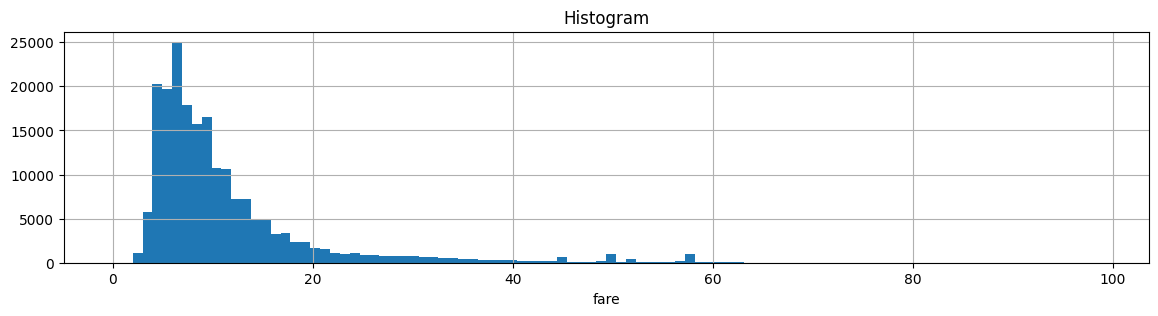

In [7]:
df_train[df_train.fare_amount<100].fare_amount.hist(bins=100, figsize=(14,3))
plt.xlabel('fare')
plt.title('Histogram')

## Remove Missing Data

In [8]:
print(df_train.isnull().sum())

key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
distance             0
dtype: int64


In [9]:
print('Old size: %d' % len(df_train))
df_train = df_train.dropna(how = 'any', axis = 'rows')
print('New size: %d' % len(df_train))

Old size: 200000
New size: 200000


## Remove Passenger Count

In [10]:
print('Old size: %d' % len(df_train))
df_train = df_train[df_train['passenger_count'].isin(df_test['passenger_count'].unique())]
print('New size: %d' % len(df_train))

pd.pivot_table(df_train, 'fare_amount', 'passenger_count', aggfunc = ['mean', 'std'])

Old size: 200000
New size: 199232


,mean,std
,fare_amount,fare_amount
passenger_count,,
1,11.188633,9.520398
2,11.850763,10.124027
3,11.468232,9.581066
4,11.709585,10.343215
5,11.310456,9.484836
6,12.312076,10.280431


## Location Data Preprocess

In [11]:
# minimum and maximum longitude test set
min(df_train.pickup_longitude.min(), df_train.dropoff_longitude.min()), \
max(df_train.pickup_longitude.max(), df_train.dropoff_longitude.max())

(-2319.206817, 40.809812)

In [12]:
# minimum and maximum latitude test
min(df_train.pickup_latitude.min(), df_train.dropoff_latitude.min()), \
max(df_train.pickup_latitude.max(), df_train.dropoff_latitude.max())

(-74.354612, 73.979805)

In [13]:
# this function will also be used with the test set below
def select_within_boundingbox(df, BB):
    return (df.pickup_longitude >= BB[0]) & (df.pickup_longitude <= BB[1]) & \
           (df.pickup_latitude >= BB[2]) & (df.pickup_latitude <= BB[3]) & \
           (df.dropoff_longitude >= BB[0]) & (df.dropoff_longitude <= BB[1]) & \
           (df.dropoff_latitude >= BB[2]) & (df.dropoff_latitude <= BB[3])

# load image of NYC map
BB = (-74.5, -72.8, 40.5, 41.8)
BB_zoom = (-74.3, -73.7, 40.5, 40.9)

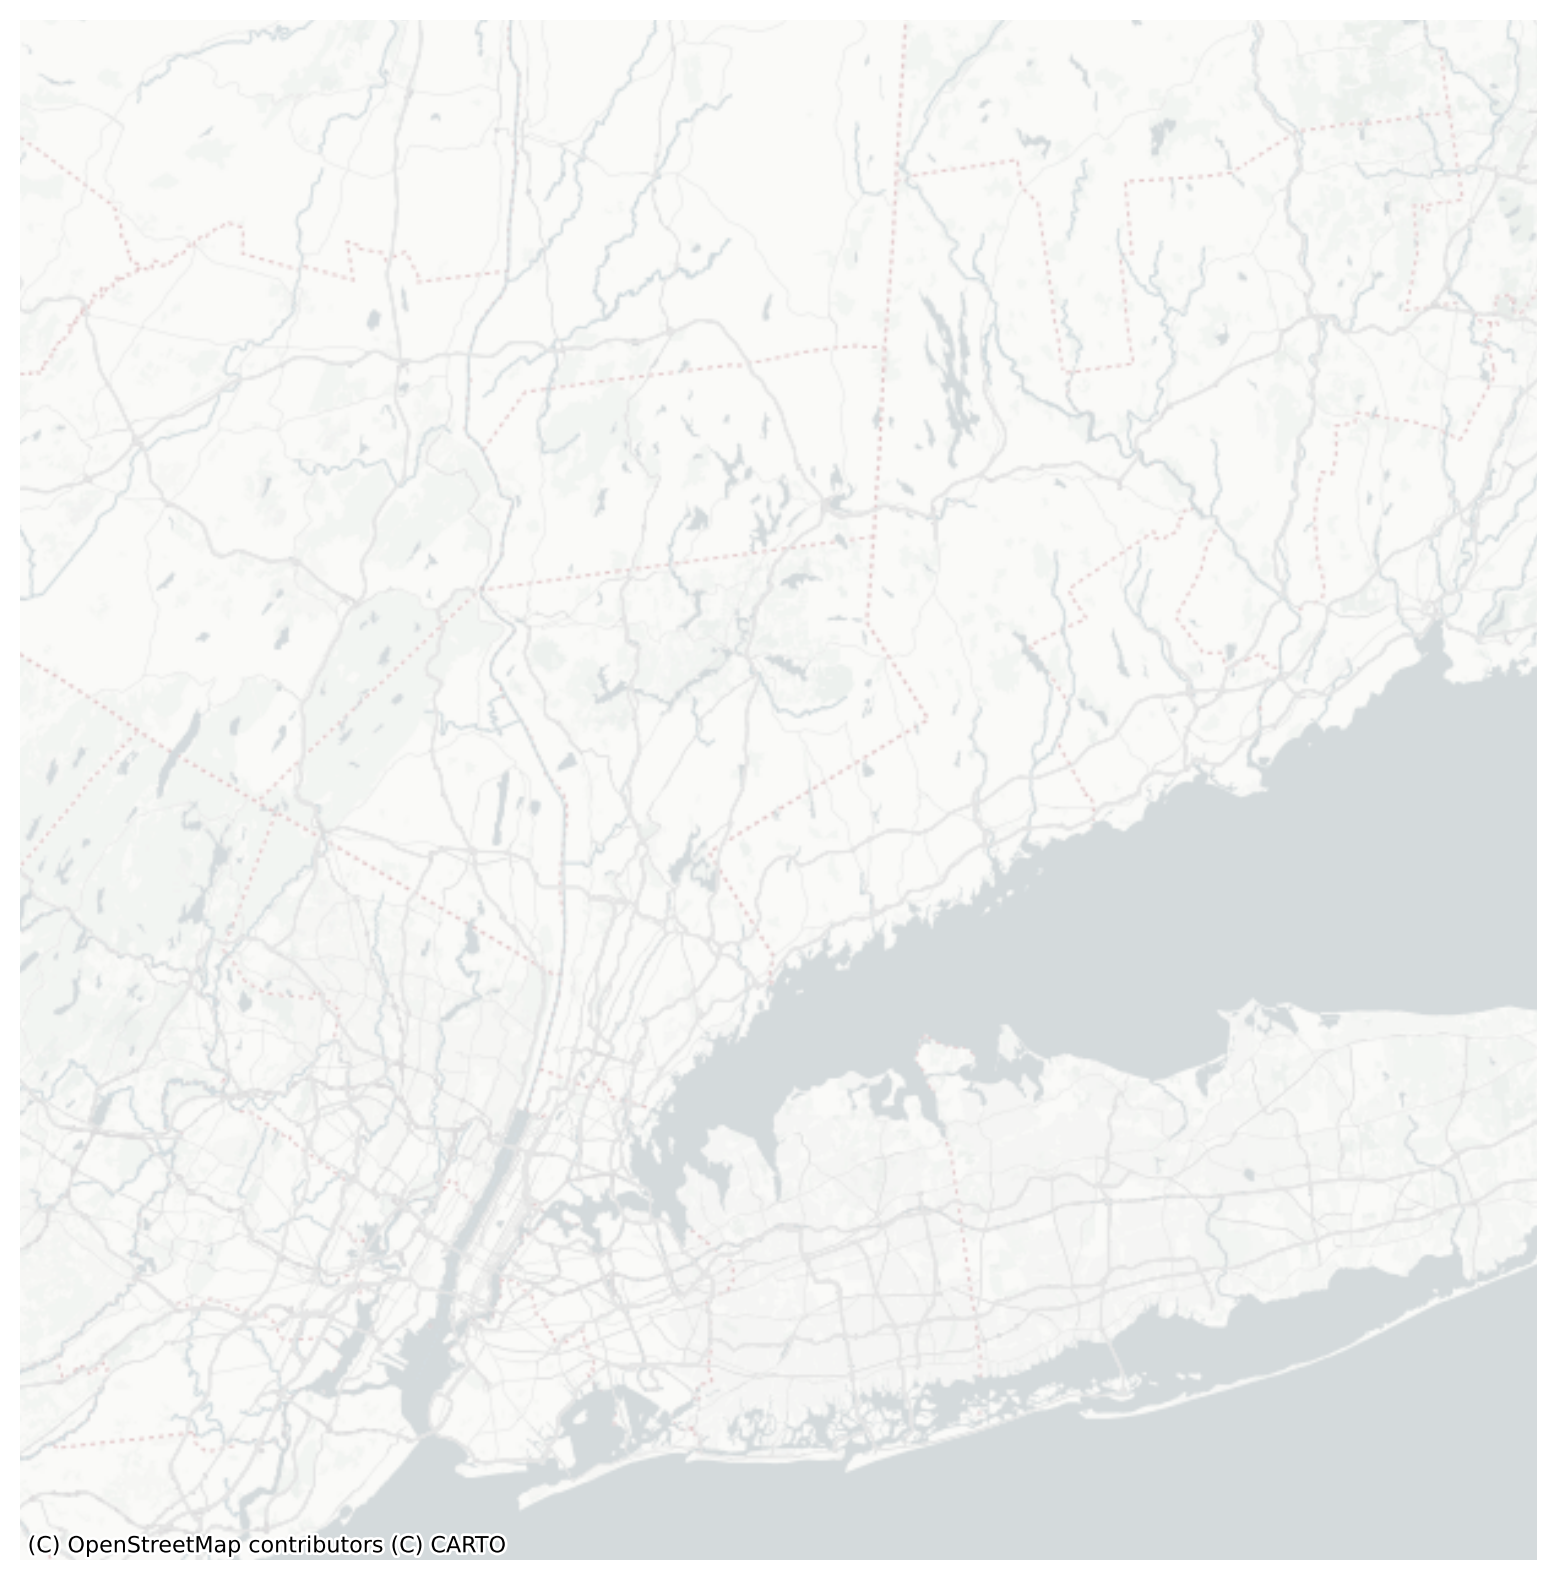

In [14]:
west, east, south, north = -74.5, -72.8, 40.5, 41.8
bbox_correct = (west, south, east, north)

# Create GeoDataFrame with correct bbox and WGS84 CRS
gdf = gpd.GeoDataFrame({"geometry":[box(*bbox_correct)]}, crs="EPSG:4326")

# Project to Web Mercator (required by most tile providers)
gdf_3857 = gdf.to_crs(epsg=3857)

# Get bounds in Web Mercator to set plot limits
minx, miny, maxx, maxy = gdf_3857.total_bounds

# Create figure sized to produce 2000x2000 pixels (figsize * dpi)
dpi = 200
figsize = (2000 / dpi, 2000 / dpi)  # (10, 10) for dpi=200

fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

# Plot an invisible polygon to set extent
gdf_3857.plot(ax=ax, alpha=0)

# Add basemap (choose a provider that is available)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)

# Limit map to bbox (in Web Mercator coords)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Remove axes and save
ax.axis("off")
plt.savefig("nyc_map_2000x2000.png", bbox_inches="tight", pad_inches=0)
plt.show()

nyc_map = np.array(Image.open("nyc_map_2000x2000.png"))

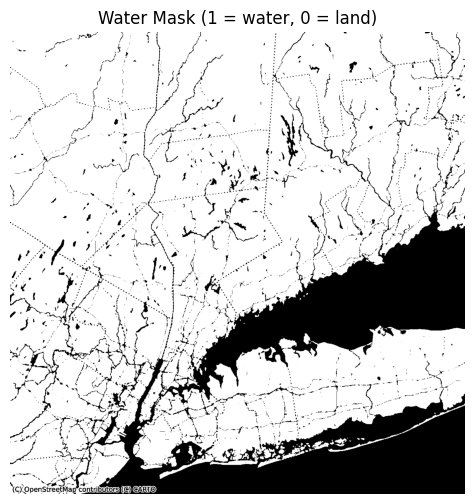

In [15]:
# Load the basemap you already saved
img = Image.open("nyc_map_2000x2000.png").convert("RGB")
arr = np.array(img)

# Compute lightness (0=black, 255=white)
lightness = arr.mean(axis=2)

# Water mask: water = 1, land = 0
# Tune threshold as needed (Positron water is very bright)
water_mask = (lightness > 230).astype(np.uint8)

# Show mask
plt.figure(figsize=(6,6))
plt.imshow(water_mask, cmap="gray")
plt.title("Water Mask (1 = water, 0 = land)")
plt.axis("off")
plt.show()

# Save mask
Image.fromarray((water_mask * 255).astype(np.uint8)).save("water_mask.png")


In [16]:
print('Old size: %d' % len(df_train))
df_train = df_train[select_within_boundingbox(df_train, BB)]
print('New size: %d' % len(df_train))

Old size: 199232
New size: 198996


In [17]:
# this function will be used more often to plot data on the NYC map
def plot_on_map(df, BB, nyc_map, s=10, alpha=0.2):
    fig, axs = plt.subplots(1, 2, figsize=(16,10))
    axs[0].scatter(df.pickup_longitude, df.pickup_latitude, zorder=1, alpha=alpha, c='r', s=s)
    axs[0].set_xlim((BB[0], BB[1]))
    axs[0].set_ylim((BB[2], BB[3]))
    axs[0].set_title('Pickup locations')
    axs[0].imshow(nyc_map, zorder=0, extent=BB)

    axs[1].scatter(df.dropoff_longitude, df.dropoff_latitude, zorder=1, alpha=alpha, c='r', s=s)
    axs[1].set_xlim((BB[0], BB[1]))
    axs[1].set_ylim((BB[2], BB[3]))
    axs[1].set_title('Dropoff locations')
    axs[1].imshow(nyc_map, zorder=0, extent=BB)

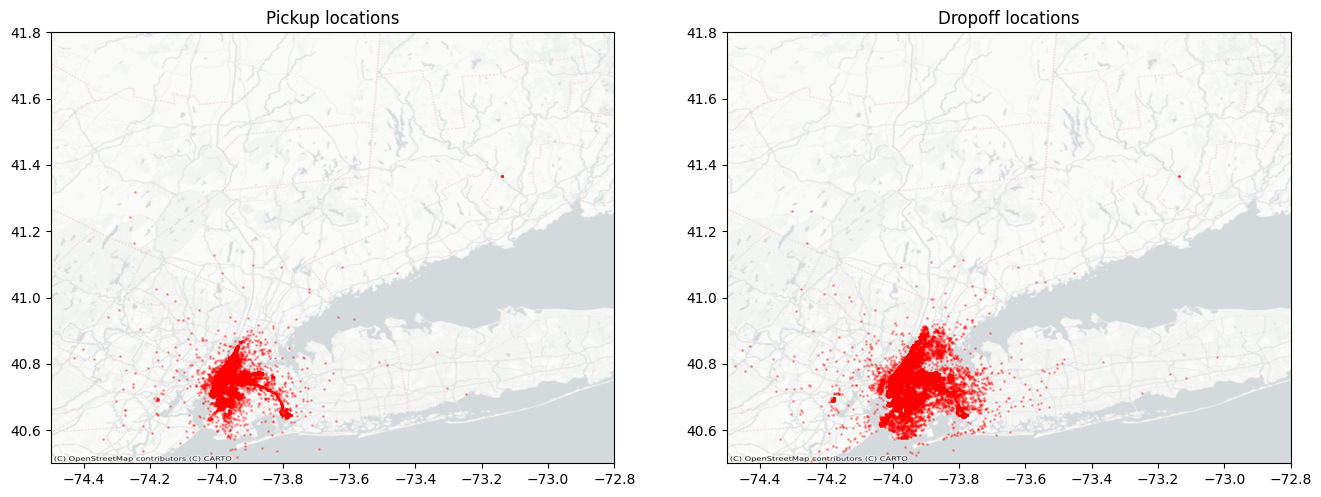

In [18]:
# plot training data on map
plot_on_map(df_train, BB, nyc_map, s=1, alpha=0.3)

In [19]:
def plot_hires(df, BB, figsize=(12, 12), ax=None, c=('r', 'b')):
    if ax == None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)

    idx = select_within_boundingbox(df, BB)
    ax.scatter(df[idx].pickup_longitude, df[idx].pickup_latitude, c=c[0], s=0.01, alpha=0.5)
    ax.scatter(df[idx].dropoff_longitude, df[idx].dropoff_latitude, c=c[1], s=0.01, alpha=0.5)

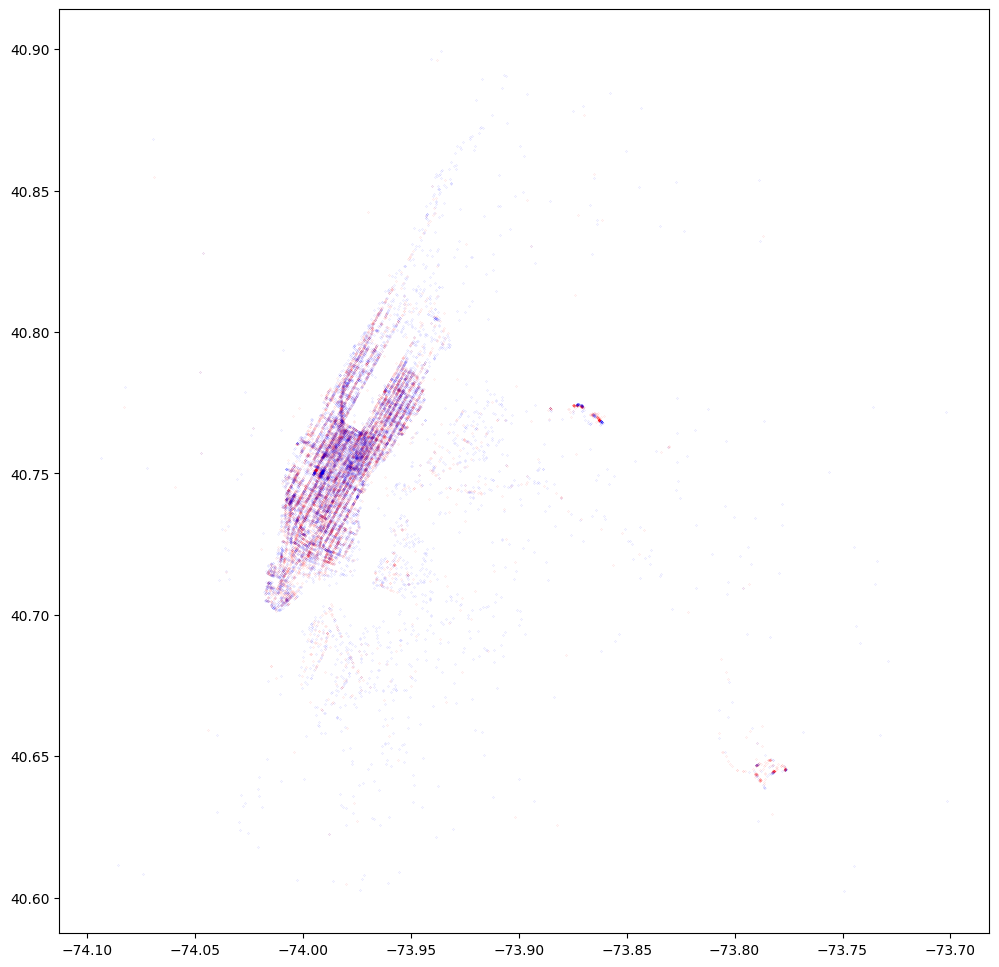

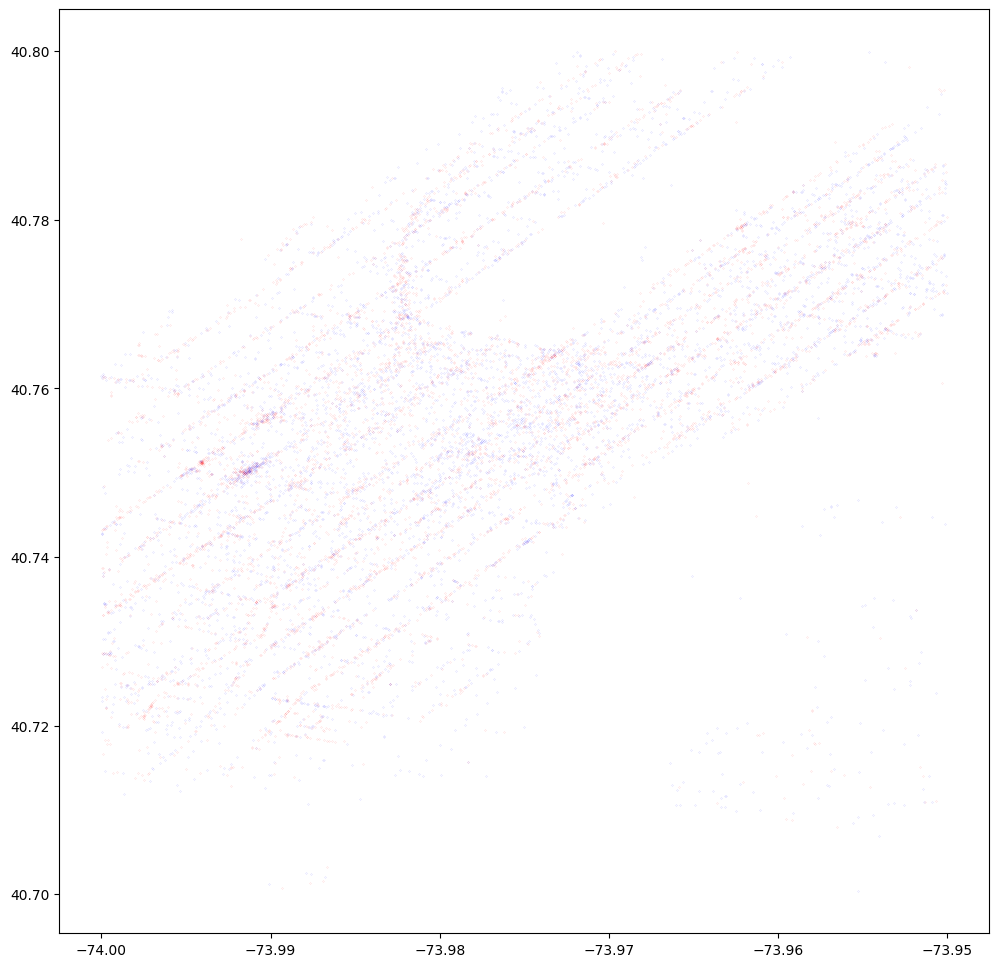

In [20]:
plot_hires(df_test, (-74.1, -73.7, 40.6, 40.9))
plot_hires(df_test, (-74, -73.95, 40.7, 40.8))

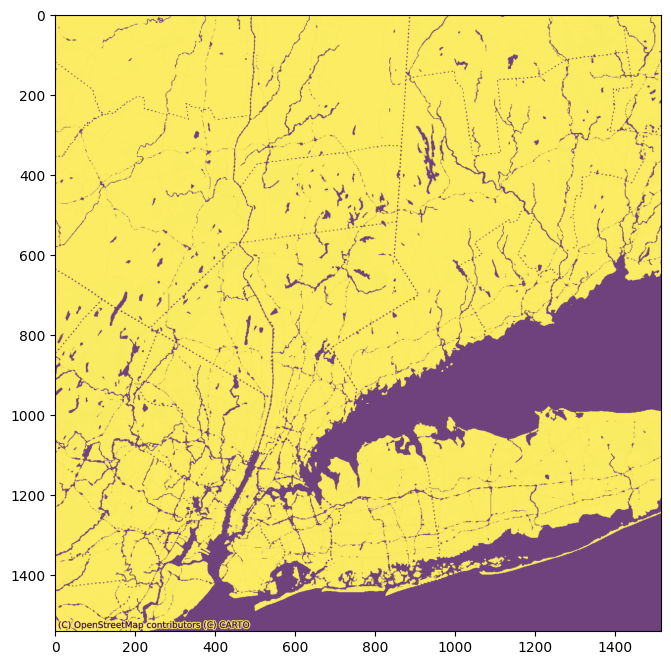

In [21]:
nyc_mask = np.array(Image.open("water_mask.png"))

plt.figure(figsize=(8,8))
plt.imshow(nyc_map, zorder=0)
plt.imshow(nyc_mask, zorder=1, alpha=0.7)

In [22]:
def lonlat_to_xy(longitude, latitude, dx, dy, BB):
    return (dx*(longitude - BB[0])/(BB[1]-BB[0])).astype('int'), \
           (dy - dy*(latitude - BB[2])/(BB[3]-BB[2])).astype('int')

In [23]:
pickup_x, pickup_y = lonlat_to_xy(df_train.pickup_longitude, df_train.pickup_latitude,
                                  nyc_mask.shape[1], nyc_mask.shape[0], BB)
dropoff_x, dropoff_y = lonlat_to_xy(df_train.dropoff_longitude, df_train.dropoff_latitude,
                                  nyc_mask.shape[1], nyc_mask.shape[0], BB)

In [24]:
idx = (nyc_mask[pickup_y, pickup_x] & nyc_mask[dropoff_y, dropoff_x])
print("Number of trips in water: {}".format(np.sum(~idx)))

Number of trips in water: 5215005


In [25]:
def remove_datapoints_from_water(df, mask_path="water_mask.png"):

    # Load the mask (single channel, 0=water, 255=land)
    mask = np.array(Image.open(mask_path))

    # Convert to boolean: True = land, False = water
    land_mask = mask > 128

    # NYC bounding box (lon_min, lon_max, lat_min, lat_max)
    BB = (-74.5, -72.8, 40.5, 41.8)

    H, W = land_mask.shape  # height, width

    # Convert longitude/latitude to pixel coordinates
    def lonlat_to_xy(lon, lat):
        x = ((lon - BB[0]) / (BB[1] - BB[0])) * W
        y = (1 - (lat - BB[2]) / (BB[3] - BB[2])) * H

        x = x.astype(int)
        y = y.astype(int)

        # clip to valid range
        x = np.clip(x, 0, W - 1)
        y = np.clip(y, 0, H - 1)
        return x, y

    # Convert pickup points
    px, py = lonlat_to_xy(df.pickup_longitude.values,
                          df.pickup_latitude.values)

    # Convert dropoff points
    dx, dy = lonlat_to_xy(df.dropoff_longitude.values,
                          df.dropoff_latitude.values)

    # Keep only trips where both pickup and dropoff are ON LAND
    on_land = land_mask[py, px] & land_mask[dy, dx]

    # Return filtered dataframe
    return df[on_land]


In [26]:
print('Old size: %d' % len(df_train))
df_train = remove_datapoints_from_water(df_train)
print('New size: %d' % len(df_train))

Old size: 198996
New size: 178545


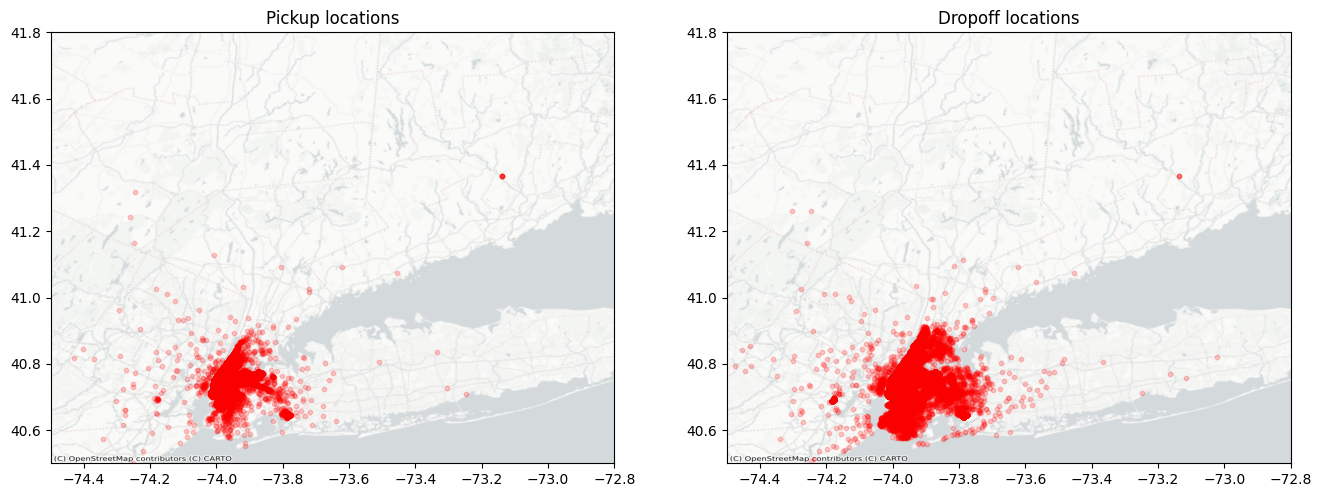

In [27]:
# plot training data
plot_on_map(df_train, BB, nyc_map)

In [28]:
# ------------------------------
# Distance function in KILOMETERS
# ------------------------------
def distance(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295  # Pi/180
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + \
        np.cos(lat1 * p) * np.cos(lat2 * p) * \
        (1 - np.cos((lon2 - lon1) * p)) / 2
    return 12742 * np.arcsin(np.sqrt(a))  # 2*R (Earth radius) but in KM

def distance(lat1, lon1, lat2, lon2):
    azimuth, cache, travelled_m = geodesic.inv(lon1, lat1, lon2, lat2)

    return azimuth, cache, travelled_m /1000

def geodesic_distance(lat1, lon1, lat2, lon2):
    # Geod.inv requires lon, lat order
    az12, az21, dist_m = geodesic.inv(lon1, lat1, lon2, lat2)
    return dist_m / 1000.0   # km


# ------------------------------
# Grid setup
# ------------------------------
n_lon, n_lat = 200, 200  # grid size
density_pickup  = np.zeros((n_lat, n_lon))
density_dropoff = np.zeros((n_lat, n_lon))

# BOUNDING BOX (same as your original)
BB = (-74.5, -72.8, 40.5, 41.8)  # west, east, south, north

# Create bins
bins_lon = np.zeros(n_lon+1)
bins_lat = np.zeros(n_lat+1)

delta_lon = (BB[1]-BB[0]) / n_lon
delta_lat = (BB[3]-BB[2]) / n_lat

# ---------------------------------------------
# NEW: bin dimensions now computed in KILOMETERS
# ---------------------------------------------
bin_width_km  = geodesic_distance(BB[2], BB[1], BB[2], BB[0]) / n_lon
bin_height_km = geodesic_distance(BB[3], BB[0], BB[2], BB[0]) / n_lat

# Fill bins
for i in range(n_lon+1):
    bins_lon[i] = BB[0] + i * delta_lon
for j in range(n_lat+1):
    bins_lat[j] = BB[2] + j * delta_lat


# ------------------------------
# Digitize datapoints into bins
# ------------------------------
inds_pickup_lon  = np.digitize(df_train.pickup_longitude, bins_lon)
inds_pickup_lat  = np.digitize(df_train.pickup_latitude,  bins_lat)
inds_dropoff_lon = np.digitize(df_train.dropoff_longitude, bins_lon)
inds_dropoff_lat = np.digitize(df_train.dropoff_latitude,  bins_lat)

# Area of each grid cell in **square kilometers**
dxdy = bin_width_km * bin_height_km


# ------------------------------
# Count points per grid cell
# ------------------------------
for i in range(n_lon):
    for j in range(n_lat):

        density_pickup[j, i] = (
            np.sum((inds_pickup_lon == i+1) &
                   (inds_pickup_lat == (n_lat - j)))
        ) / dxdy

        density_dropoff[j, i] = (
            np.sum((inds_dropoff_lon == i+1) &
                   (inds_dropoff_lat == (n_lat - j)))
        ) / dxdy


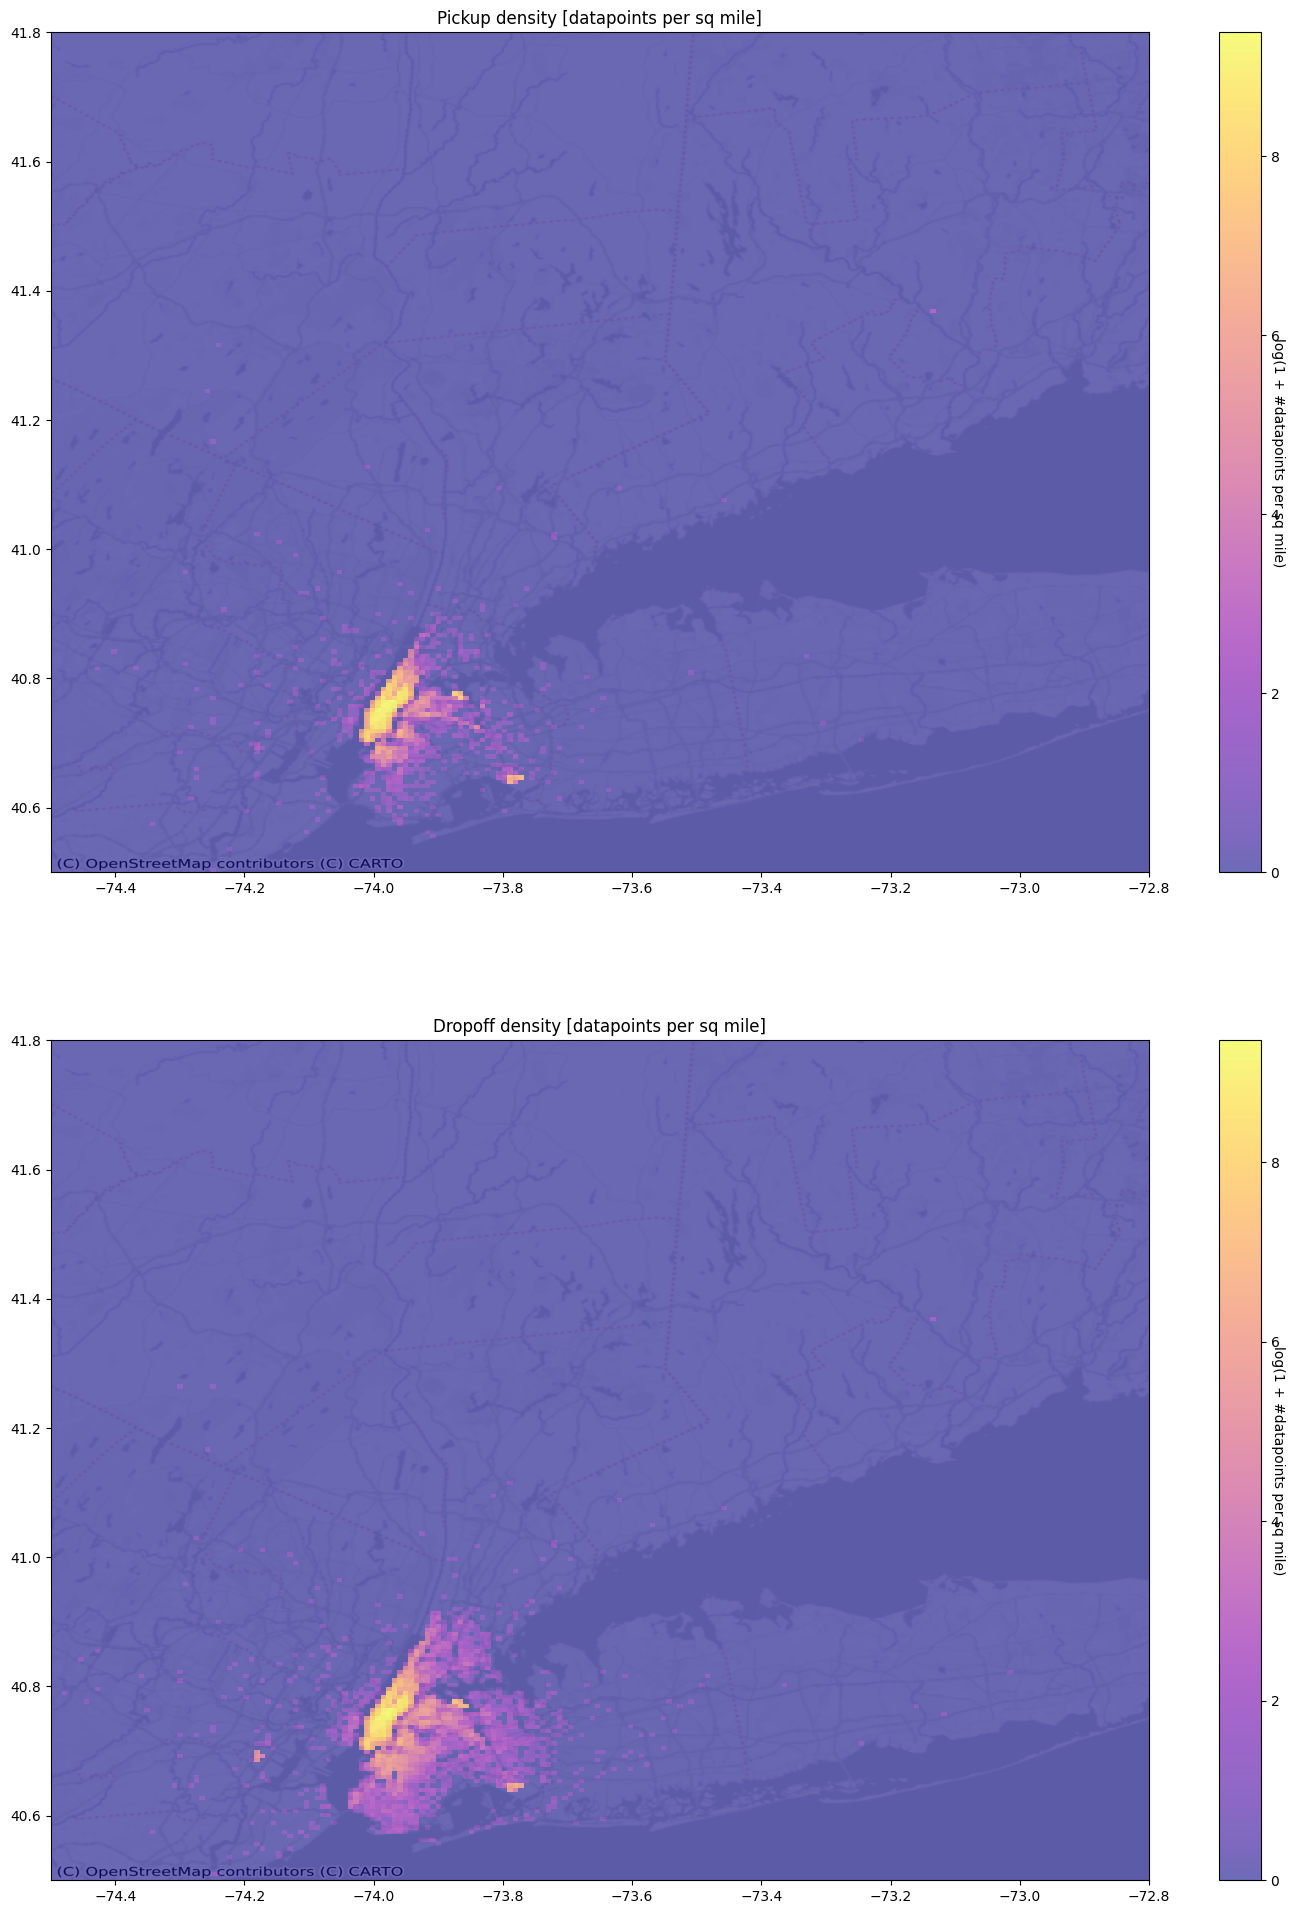

In [29]:
# Plot the density arrays
fig, axs = plt.subplots(2, 1, figsize=(18, 24))
axs[0].imshow(nyc_map, zorder=0, extent=BB);
im = axs[0].imshow(np.log1p(density_pickup), zorder=1, extent=BB, alpha=0.6, cmap='plasma')
axs[0].set_title('Pickup density [datapoints per sq mile]')
cbar = fig.colorbar(im, ax=axs[0])
cbar.set_label('log(1 + #datapoints per sq mile)', rotation=270)

axs[1].imshow(nyc_map, zorder=0, extent=BB);
im = axs[1].imshow(np.log1p(density_dropoff), zorder=1, extent=BB, alpha=0.6, cmap='plasma')
axs[1].set_title('Dropoff density [datapoints per sq mile]')
cbar = fig.colorbar(im, ax=axs[1])
cbar.set_label('log(1 + #datapoints per sq mile)', rotation=270)

In [30]:
# add time information
df_train['year'] = df_train.pickup_datetime.apply(lambda t: t.year)
# df_train['weekday'] = df_train.pickup_datetime.apply(lambda t: t.weekday())
df_train['hour'] = df_train.pickup_datetime.apply(lambda t: t.hour)

,distance_kilometer
count,178545.000000
mean,3.214211
std,3.435391
min,0.000084
25%,1.248499
50%,2.120807
75%,3.806869
max,103.233970


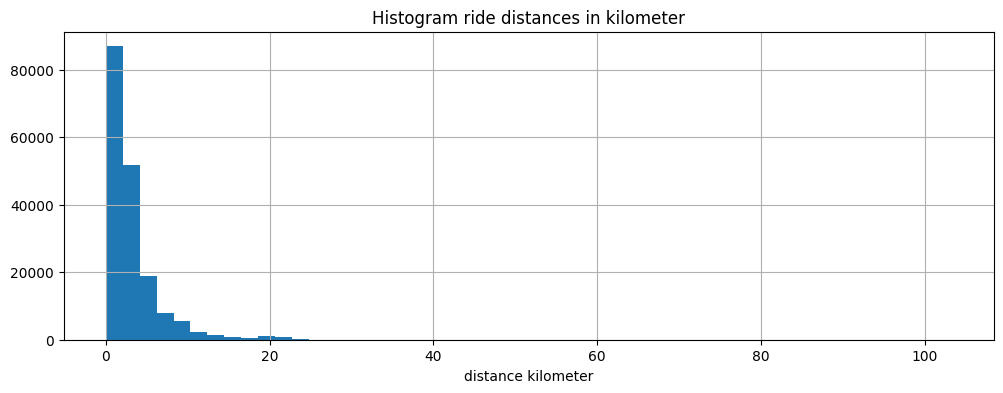

In [31]:
# add new column to dataframe with distance in miles
df_train['azimuth'], cache, df_train['distance_kilometer'] = distance(df_train.pickup_latitude, df_train.pickup_longitude, \
                                      df_train.dropoff_latitude, df_train.dropoff_longitude)

df_test['azimuth'], cache, df_test['distance_kilometer'] = distance(df_test.pickup_latitude, df_test.pickup_longitude, \
                                      df_test.dropoff_latitude, df_test.dropoff_longitude)

df_train.distance_kilometer.hist(bins=50, figsize=(12,4))
plt.xlabel('distance kilometer')
plt.title('Histogram ride distances in kilometer')
df_train.distance_kilometer.describe()

In [32]:
df_train.loc[df_train['distance_kilometer'] > 70, 'distance_kilometer'] = df_train['distance_kilometer'].median()
df_test.loc[df_test['distance_kilometer'] > 70, 'distance_kilometer'] = df_test['distance_kilometer'].median()
df_train = df_train[df_train['fare_amount'] < 300]

In [33]:
# # remove datapoints with distance <0.1 kilometer
# idx = (df_train.distance_kilometer >= 0.1)
# print('Old size: %d' % len(df_train))
# df_train = df_train[idx]
# print('New size: %d' % len(df_train))

df_train['fare_amount'] = abs(df_train['fare_amount'])

print('Old size: %d' % len(df_train))
df_train = df_train[df_train['fare_amount'] >=1]
print('New size: %d' % len(df_train))

Old size: 178545
New size: 178543


In [34]:
# JFK airport coordinates, see https://www.travelmath.com/airport/JFK


def plot_location_fare(loc, name, range=1.5):
    # select all datapoints with dropoff location within range of airport
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    idx = (distance(df_train.pickup_latitude, df_train.pickup_longitude, loc[1], loc[0]) < range)
    df_train[idx].fare_amount.hist(bins=100, ax=axs[0])
    axs[0].set_xlabel('fare')
    axs[0].set_title('Histogram pickup location within {} miles of {}'.format(range, name))

    idx = (distance(df_train.dropoff_latitude, df_train.dropoff_longitude, loc[1], loc[0]) < range)
    df_train[idx].fare_amount.hist(bins=100, ax=axs[1])
    axs[1].set_xlabel('fare')
    axs[1].set_title('Histogram dropoff location within {} miles of {}'.format(range, name))

In [35]:
ewr = (-74.175, 40.69) # Newark Liberty International Airport, see https://www.travelmath.com/airport/EWR
lgr = (-73.87, 40.77) # LaGuardia Airport, see https://www.travelmath.com/airport/LGA
jfk = (-73.7822222222, 40.6441666667)
nyc = (-74.0063889, 40.7141667)
# plot_location_fare(ewr, 'Newark Airport')
# plot_location_fare(lgr, 'LaGuardia Airport')
# plot_location_fare(jfk, 'JFK Airport')

In [36]:
df_train['fare_per_kilometer'] = df_train.fare_amount / df_train.distance_kilometer
df_train.fare_per_kilometer.describe()

,fare_per_kilometer
count,178543.000000
mean,83.421914
std,5010.666742
min,0.127700
25%,2.992558
50%,3.851373
75%,5.102792
max,986360.939870


/tmp/ipython-input-3901894471.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pickup_masker = pd.pivot_table(df_train, 'fare_amount', 'pickup_latitude_cat', 'pickup_longitude_cat', 'count')>20
/tmp/ipython-input-3901894471.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pickup_medians = (pd.pivot_table(df_train, 'fare_amount', 'pickup_latitude_cat', 'pickup_longitude_cat', 'median')*pickup_masker).fillna(0).sort_index(ascending = False)
/tmp/ipython-input-3901894471.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain 

Text(1887.7676767676764, 0.5, '')

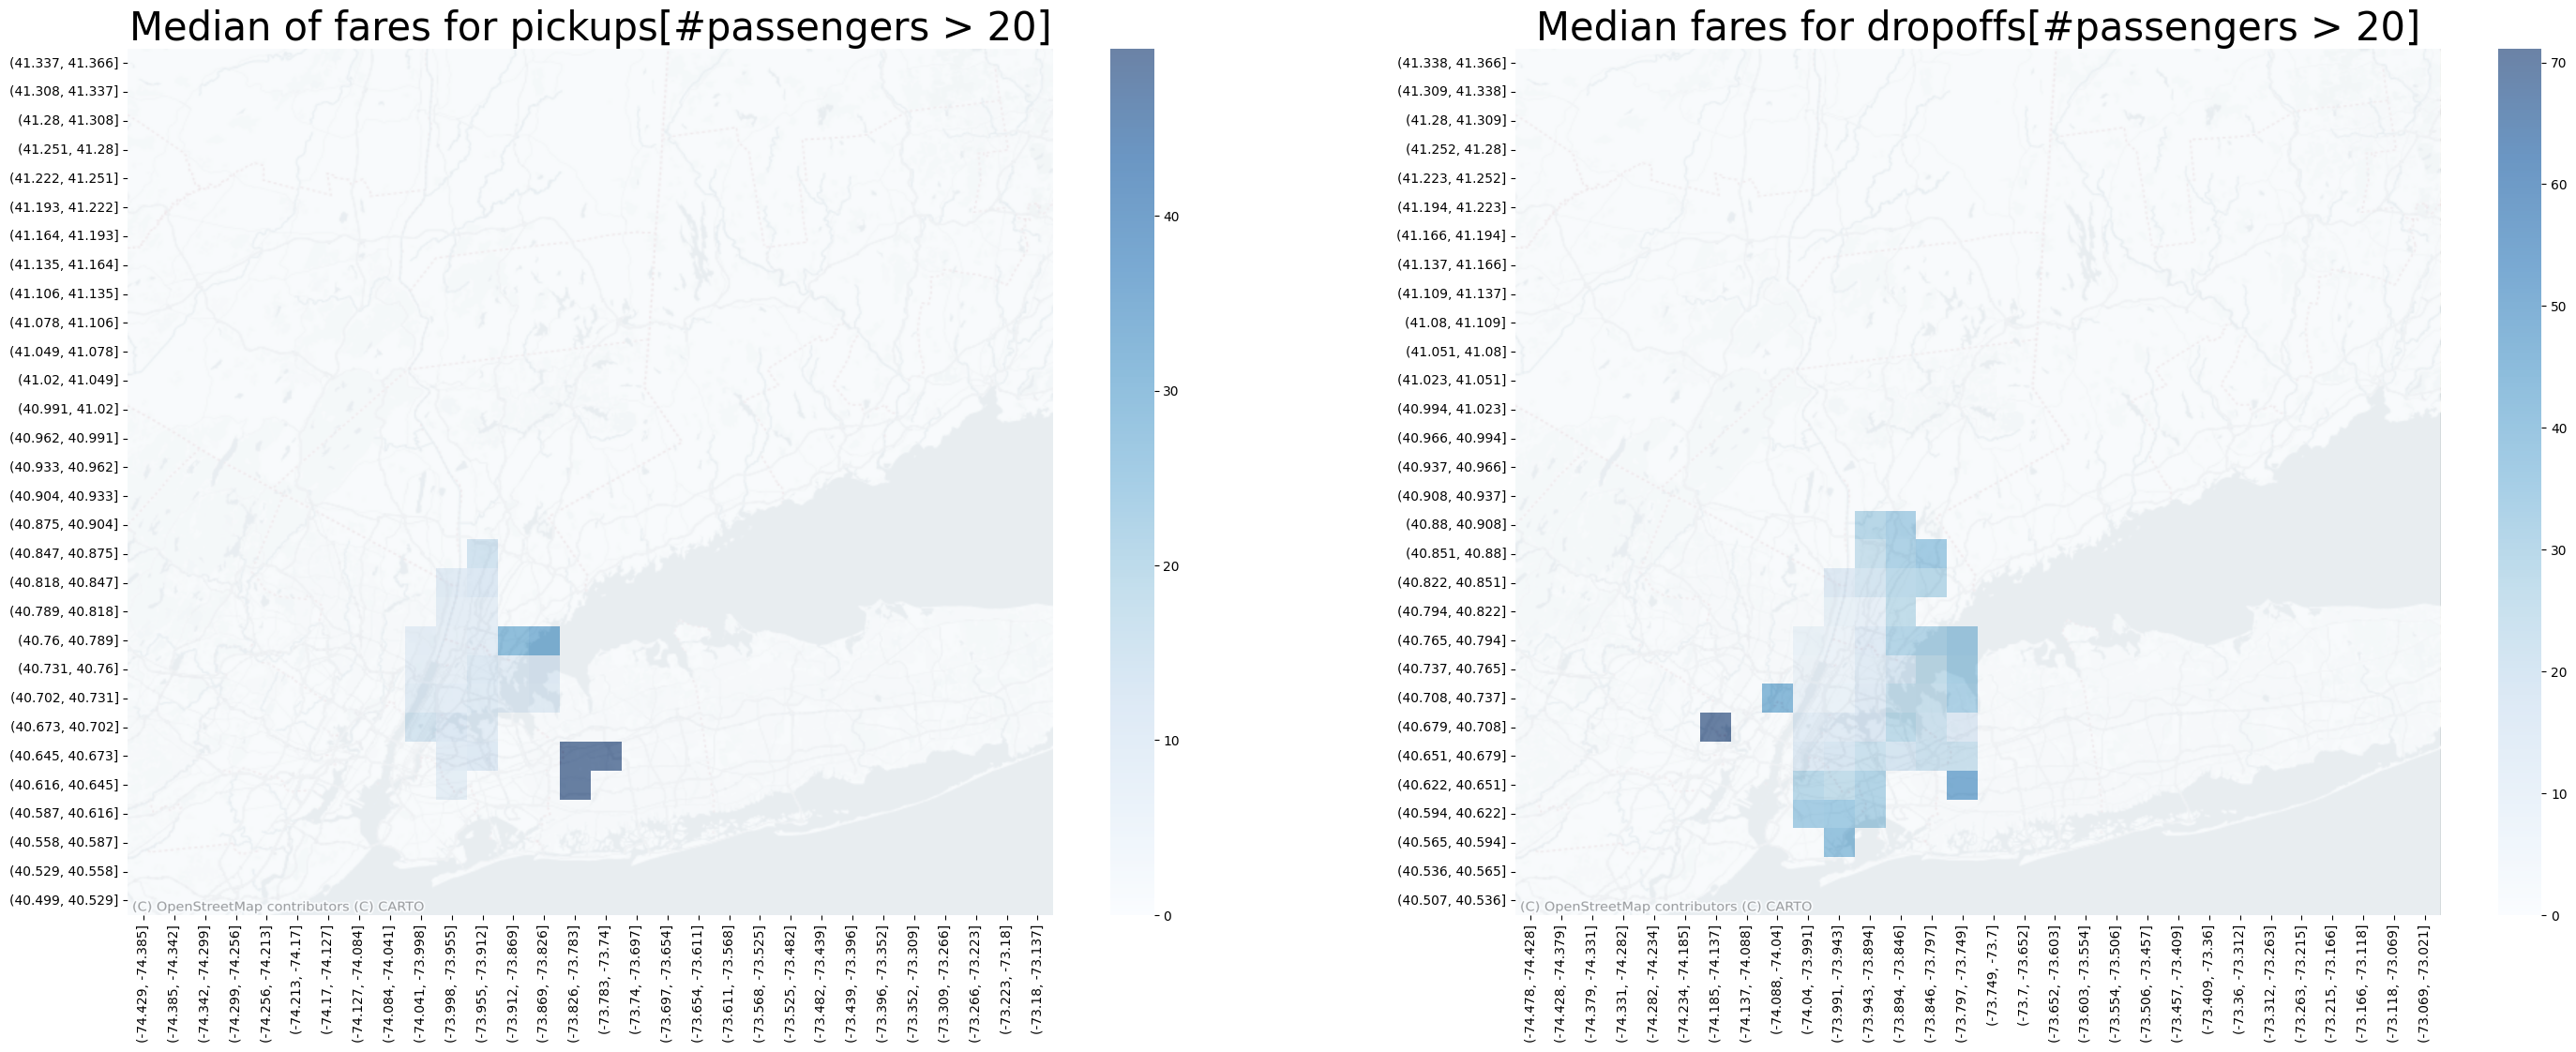

In [37]:
n_cat = 30
df_train['pickup_longitude_cat']  = pd.cut(df_train['pickup_longitude'],  n_cat)
df_train['pickup_latitude_cat']   = pd.cut(df_train['pickup_latitude'],   n_cat)
df_train['dropoff_longitude_cat'] = pd.cut(df_train['dropoff_longitude'], n_cat)
df_train['dropoff_latitude_cat']  = pd.cut(df_train['dropoff_latitude'],  n_cat)

pickup_masker = pd.pivot_table(df_train, 'fare_amount', 'pickup_latitude_cat', 'pickup_longitude_cat', 'count')>20
pickup_medians = (pd.pivot_table(df_train, 'fare_amount', 'pickup_latitude_cat', 'pickup_longitude_cat', 'median')*pickup_masker).fillna(0).sort_index(ascending = False)
dropoff_masker = pd.pivot_table(df_train, 'fare_amount', 'dropoff_latitude_cat', 'dropoff_longitude_cat', 'count')>20
dropoff_medians = (pd.pivot_table(df_train, 'fare_amount', 'dropoff_latitude_cat', 'dropoff_longitude_cat', 'median')*dropoff_masker).fillna(0).sort_index(ascending = False)

f, axes = plt.subplots(1, 2, figsize = (35, 12))
pickup_hmap = sns.heatmap(pickup_medians, alpha = 0.6, zorder = 2, ax = axes[0], cmap = 'Blues')
pickup_hmap.imshow(nyc_map, aspect = pickup_hmap.get_aspect(),
                   extent = pickup_hmap.get_xlim() + pickup_hmap.get_ylim(), zorder = 1)

pickup_hmap.set_title('Median of fares for pickups[#passengers > 20]', fontsize = 30)
pickup_hmap.set_xlabel('')
pickup_hmap.set_ylabel('')

dropoff_hmap = sns.heatmap(dropoff_medians, alpha = 0.6, zorder = 2, ax = axes[1], cmap = 'Blues')
dropoff_hmap.imshow(nyc_map, aspect = dropoff_hmap.get_aspect(),
                    extent = dropoff_hmap.get_xlim() + dropoff_hmap.get_ylim(), zorder = 1)

dropoff_hmap.set_title('Median fares for dropoffs[#passengers > 20]', fontsize = 30)
dropoff_hmap.set_xlabel('')
dropoff_hmap.set_ylabel('')

Text(0, 0.5, 'Fare / kilo')

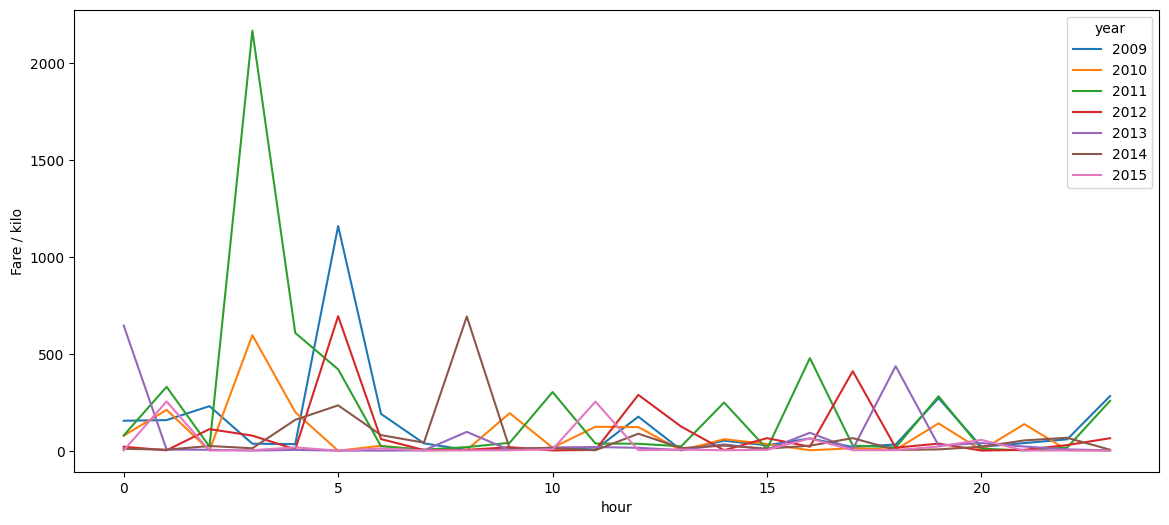

In [38]:
df_train.pivot_table('fare_per_kilometer', index='hour', columns='year').plot(figsize=(14,6))
plt.ylabel('Fare / kilo')

In [39]:
NYC_long = -74.0060
NYC_lat  = 40.7128

df_train['center_to_pickup_azimuth'], cache, df_train['center_to_pickup_km'] = geodesic.inv(
    np.full(df_train.shape[0], NYC_long), np.full(df_train.shape[0], NYC_lat),
    df_train['pickup_longitude'].values, df_train['pickup_latitude'].values
)
df_train['center_to_dropoff_azimuth'], cache, df_train['center_to_dropoff_km'] = geodesic.inv(
    np.full(df_train.shape[0], NYC_long), np.full(df_train.shape[0], NYC_lat),
    df_train['dropoff_longitude'].values, df_train['dropoff_latitude'].values
)
df_test['center_to_pickup_azimuth'], cache, df_test['center_to_pickup_km'] = geodesic.inv(
    np.full(df_test.shape[0], NYC_long), np.full(df_test.shape[0], NYC_lat),
    df_test['pickup_longitude'].values, df_test['pickup_latitude'].values
)
df_test['center_to_dropoff_azimuth'], cache, df_test['center_to_dropoff_km'] = geodesic.inv(
    np.full(df_test.shape[0], NYC_long), np.full(df_test.shape[0], NYC_lat),
    df_test['dropoff_longitude'].values, df_test['dropoff_latitude'].values
)

#From meters to kilometers
df_train[['center_to_pickup_km', 'center_to_dropoff_km']] = df_train[['center_to_pickup_km', 'center_to_dropoff_km']]/1000
df_test[['center_to_pickup_km', 'center_to_dropoff_km']] = df_test[['center_to_pickup_km', 'center_to_dropoff_km']]/1000

In [40]:
def add_datetime_features(data):
    data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])
    data['date']            = data['pickup_datetime'].dt.date
    data['year']            = data['pickup_datetime'].dt.year
    data['month']           = data['pickup_datetime'].dt.month_name()
    data['week']            = data['pickup_datetime'].dt.isocalendar().week
    data['day']             = data['pickup_datetime'].dt.day
    data['hour']            = data['pickup_datetime'].dt.hour
    data['day_of_week']     = data['pickup_datetime'].dt.day_name()

    return data

df_train = add_datetime_features(df_train).sort_values('pickup_datetime') #Sorting for future plots.
df_test = add_datetime_features(df_test)

In [41]:
df_train['after_2012sep'] = (df_train['pickup_datetime'] >= '2012-09-01')*1
df_test['after_2012sep'] = (df_test['pickup_datetime'] >= '2012-09-01')*1

Text(0.5, 1.0, 'Median fare each day')

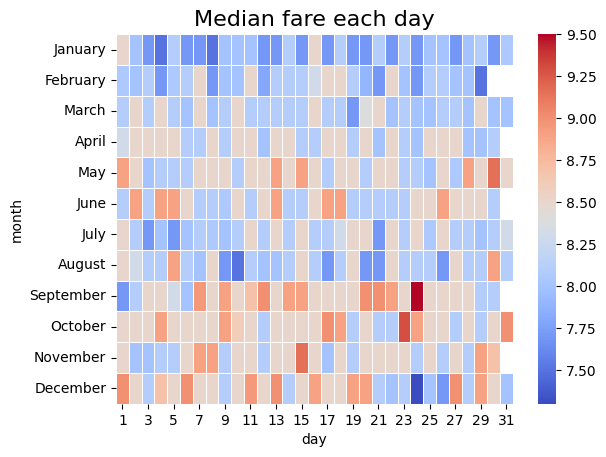

In [42]:
months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']

fare_month_day_cross = pd.pivot_table(df_train, 'fare_amount', 'month', 'day', 'median').reindex(months)
sns.heatmap(fare_month_day_cross, linewidths = 0.5, cmap="coolwarm")
plt.title('Median fare each day', fontsize = 16)

Text(0.5, 1.0, 'Mean fares by weekdays')

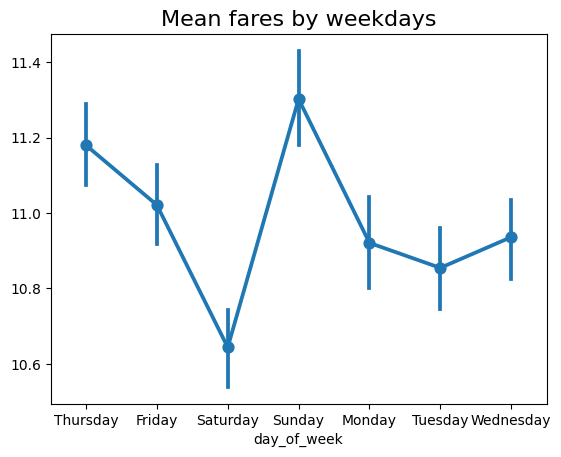

In [43]:
sns.pointplot(x = 'day_of_week', y = 'fare_amount', data = df_train)
plt.ylabel('')
plt.title('Mean fares by weekdays', fontsize = 16)

Text(0.5, 1.0, 'Mean fares by days of months')

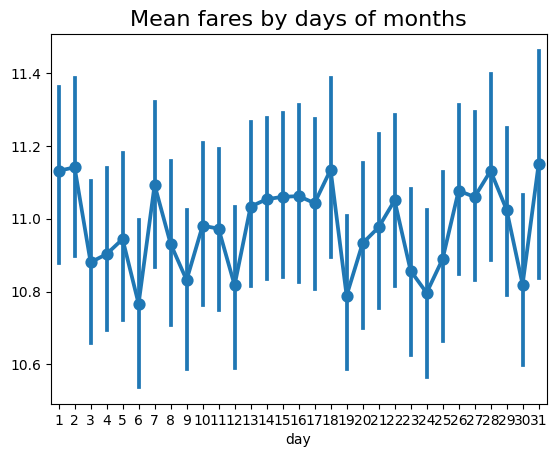

In [44]:
sns.pointplot(x = 'day', y = 'fare_amount', data = df_train)
plt.ylabel('')
plt.title('Mean fares by days of months', fontsize = 16)

Text(0.5, 1.0, 'Mean fares by days of months')

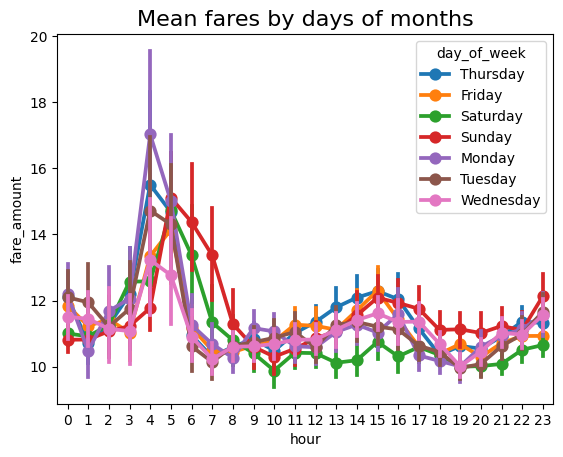

In [45]:
sns.pointplot(x = 'hour', y = 'fare_amount', data = df_train, hue = 'day_of_week')
plt.title('Mean fares by days of months', fontsize = 16)

In [46]:
url = 'https://raw.githubusercontent.com/zonination/weather-us/master/nyc.csv'
weather = pd.read_csv(url, index_col=0)
weather.head()

,Date,Max.TemperatureF,Mean.TemperatureF,Min.TemperatureF,Max.Dew.PointF,MeanDew.PointF,Min.DewpointF,Max.Humidity,Mean.Humidity,Min.Humidity,...,Min.VisibilityMiles,Max.Wind.SpeedMPH,Mean.Wind.SpeedMPH,Max.Gust.SpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees.br...,city,season
1,1948-07-01,84,78.0,72,71,65,58,93,65,46,...,2.0,16,8,NaN,0.00,0.0,Fog,264<br />,New York City (USA),Summer
2,1948-07-02,82,72.0,63,62,53,49,76,51,33,...,10.0,16,10,NaN,0.00,0.0,NaN,315<br />,New York City (USA),Summer
3,1948-07-03,78,71.0,64,66,58,53,84,62,42,...,5.0,14,6,NaN,0.00,0.0,NaN,203<br />,New York City (USA),Summer
4,1948-07-04,84,76.0,68,68,63,56,90,67,38,...,2.0,12,5,NaN,0.00,0.0,Fog,198<br />,New York City (USA),Summer
5,1948-07-05,93,82.0,70,74,69,65,93,71,40,...,3.0,18,8,NaN,0.00,0.0,Fog-Rain-Thunderstorm,218<br />,New York City (USA),Summer


In [47]:
weather['date'] = pd.to_datetime(weather['Date'])
weather = weather.loc[weather['date'] > '2008-12-31',['date','Mean.TemperatureF','Mean.Wind.SpeedMPH','Events']]
weather['Events'] = weather['Events'].fillna('unknown')
weather['Mean.Wind.SpeedMPH'] = weather['Mean.Wind.SpeedMPH'].fillna(weather['Mean.Wind.SpeedMPH'].mean())
weather['Mean.TemperatureC'] = weather['Mean.TemperatureF'].apply(lambda F: (F-32)*5/9)
weather['Mean.TemperatureC'] = weather['Mean.TemperatureC'].fillna(weather['Mean.TemperatureC'].mean())

weather = weather.drop('Mean.TemperatureF', axis = 1)
weather.head()

,date,Mean.Wind.SpeedMPH,Events,Mean.TemperatureC
22066,2009-01-01,19,unknown,-5.555556
22067,2009-01-02,13,Snow,-1.111111
22068,2009-01-03,17,unknown,2.222222
22069,2009-01-04,12,unknown,1.666667
22070,2009-01-05,10,Rain,5.000000


In [48]:
def merge_weather(data):
    data['date'] = pd.to_datetime(data['date'])
    data = data.merge(weather, 'left', 'date')

    return data

df_train = merge_weather(df_train)
df_test = merge_weather(df_test)

Text(0.5, 1.0, 'Scatterplot of Wind Speed vs Fare')

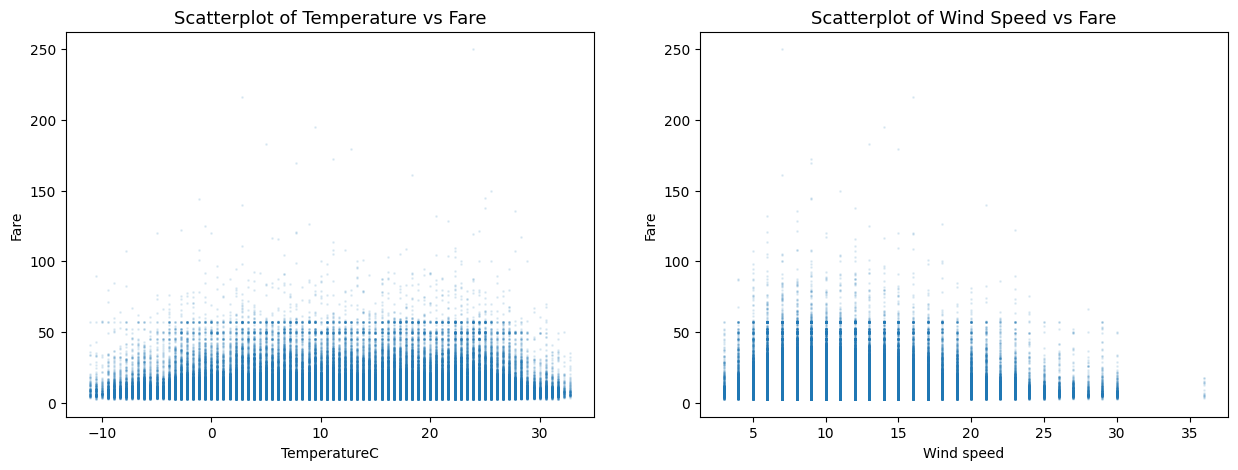

In [49]:
fig, axs = plt.subplots(ncols=2, figsize = (15,5))

axs[0].scatter(x = df_train['Mean.TemperatureC'], y = df_train['fare_amount'], alpha = 0.1, s = 1)
axs[0].set_xlabel('TemperatureC')
axs[0].set_ylabel('Fare')
axs[0].set_title('Scatterplot of Temperature vs Fare', fontsize = 13)

axs[1].scatter(x = df_train['Mean.Wind.SpeedMPH'], y = df_train['fare_amount'], alpha = 0.1, s = 1)
axs[1].set_xlabel('Wind speed')
axs[1].set_ylabel('Fare')
axs[1].set_title('Scatterplot of Wind Speed vs Fare', fontsize = 13)

Text(0.5, 1.0, 'Distribution of Events [Test]')

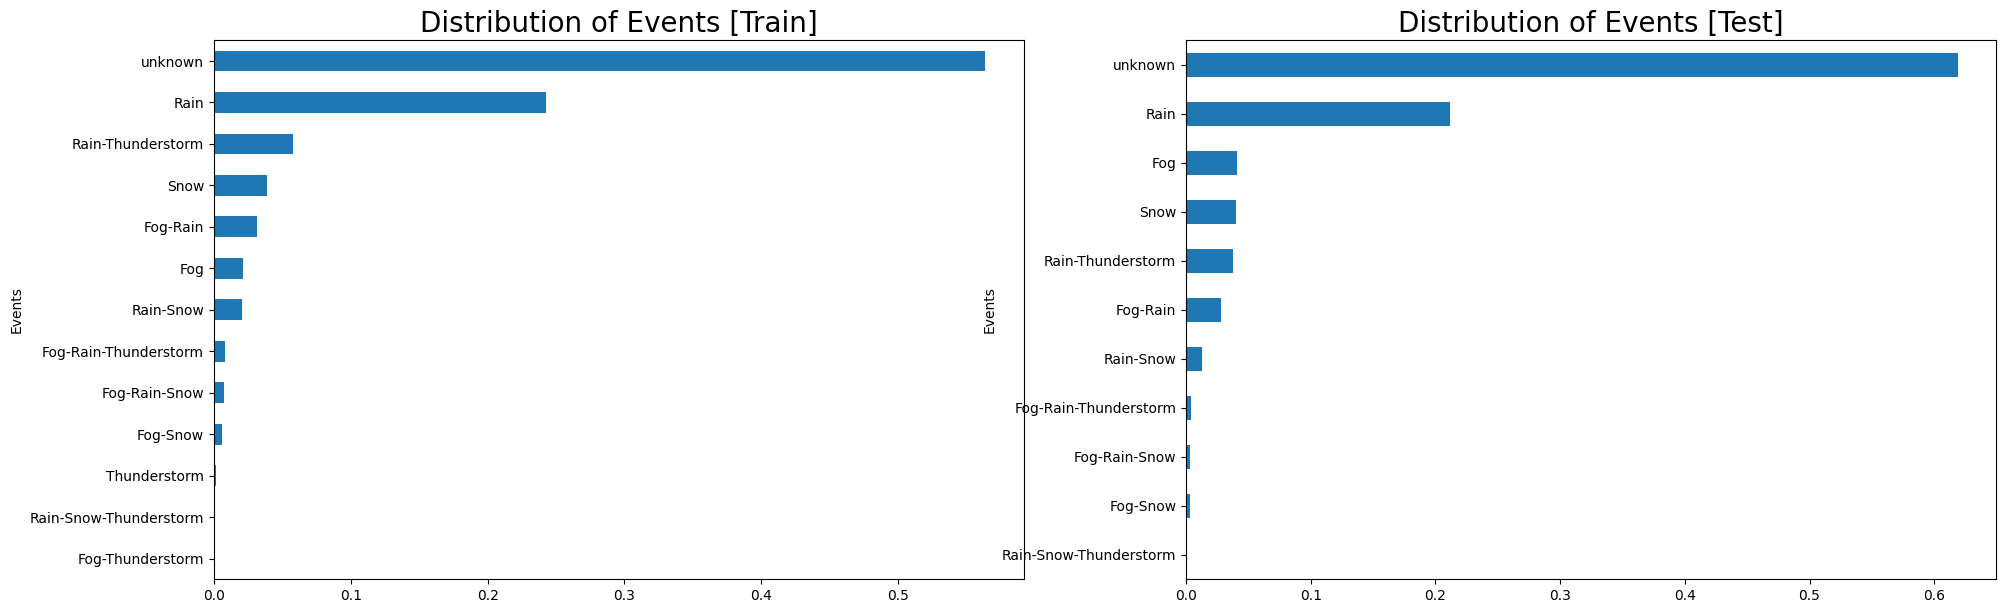

In [50]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize = (23,7))
df_train['Events'].value_counts(normalize = 'columns').sort_values().plot(kind = 'barh', ax = axes[0])
df_test['Events'].value_counts(normalize = 'columns').sort_values().plot(kind = 'barh', ax = axes[1])
axes[0].set_title('Distribution of Events [Train]', fontsize = 20)
axes[1].set_title('Distribution of Events [Test]', fontsize = 20)

/tmp/ipython-input-4127940489.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


Text(0.5, 1.0, 'Mean of fares amount by Events')

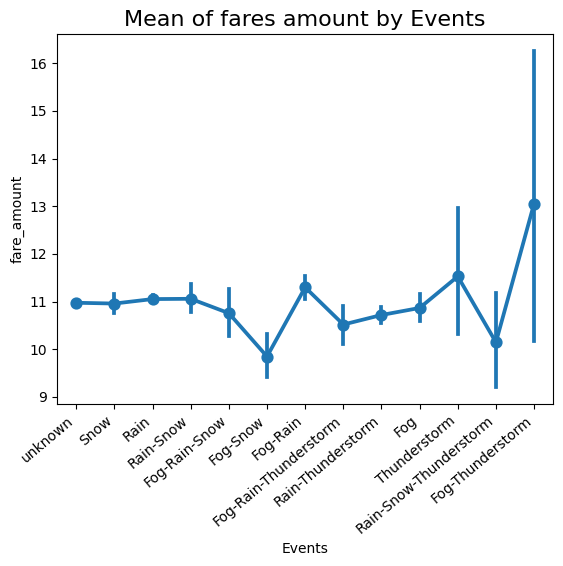

In [51]:
ax = sns.pointplot(x = 'Events', y = 'fare_amount', data = df_train)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
ax.set_title('Mean of fares amount by Events', fontsize = 16)

In [52]:
# --------------------------------------
# Add interaction features (recommended)
# --------------------------------------

# 1. pickup_longitude × pickup_latitude
df_train["pickup_lonlat_interaction"] = (
    df_train["pickup_longitude"] * df_train["pickup_latitude"]
)
df_test["pickup_lonlat_interaction"] = (
    df_test["pickup_longitude"] * df_test["pickup_latitude"]
)

# 2. dropoff_longitude × dropoff_latitude
df_train["dropoff_lonlat_interaction"] = (
    df_train["dropoff_longitude"] * df_train["dropoff_latitude"]
)
df_test["dropoff_lonlat_interaction"] = (
    df_test["dropoff_longitude"] * df_test["dropoff_latitude"]
)

# 3. distance_kilometer × azimuth
df_train["distance_azimuth_interaction"] = (
    df_train["distance_kilometer"] * df_train["azimuth"]
)
df_test["distance_azimuth_interaction"] = (
    df_test["distance_kilometer"] * df_test["azimuth"]
)

# 4. center_to_pickup_km × center_to_pickup_azimuth
df_train["center_pickup_interaction"] = (
    df_train["center_to_pickup_km"] * df_train["center_to_pickup_azimuth"]
)
df_test["center_pickup_interaction"] = (
    df_test["center_to_pickup_km"] * df_test["center_to_pickup_azimuth"]
)

# 5. center_to_dropoff_km × center_to_dropoff_azimuth
df_train["center_dropoff_interaction"] = (
    df_train["center_to_dropoff_km"] * df_train["center_to_dropoff_azimuth"]
)
df_test["center_dropoff_interaction"] = (
    df_test["center_to_dropoff_km"] * df_test["center_to_dropoff_azimuth"]
)

# 6. pickup_latitude × dropoff_latitude  (a simple directional interaction)
df_train["pickup_dropoff_lat_interaction"] = (
    df_train["pickup_latitude"] * df_train["dropoff_latitude"]
)
df_test["pickup_dropoff_lat_interaction"] = (
    df_test["pickup_latitude"] * df_test["dropoff_latitude"]
)


In [53]:
# -----------------------------
# 2. Feature Engineering
# -----------------------------
df_train["pickup_datetime"] = pd.to_datetime(df_train["pickup_datetime"])
df_train["date"] = pd.to_datetime(df_train["date"])
df_train["week"] = df_train["week"].astype(int)
df_train["Events"] = df_train["Events"].astype("category").cat.codes

df_train['month'] = df_train['pickup_datetime'].dt.month
df_train['day_of_week'] = df_train['pickup_datetime'].dt.weekday

df_test["pickup_datetime"] = pd.to_datetime(df_test["pickup_datetime"])
df_test["date"] = pd.to_datetime(df_test["date"])
df_test["week"] = df_test["week"].astype(int)
df_test["Events"] = df_test["Events"].astype("category").cat.codes

df_test['month'] = df_test['pickup_datetime'].dt.month
df_test['day_of_week'] = df_test['pickup_datetime'].dt.weekday



# -----------------------------
# 3. Select features and target
# -----------------------------
features = [
    # 'key',
#  'fare_amount',
#  'pickup_datetime',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count',
 'year',
#  'weekday',
 'hour',
 'azimuth',
 'distance_kilometer',
#  'fare_per_kilometer',
#  'pickup_longitude_cat',
#  'pickup_latitude_cat',
#  'dropoff_longitude_cat',
#  'dropoff_latitude_cat',
 'center_to_pickup_azimuth',
 'center_to_pickup_km',
 'center_to_dropoff_azimuth',
 'center_to_dropoff_km',
#  'date',
#  'month',
#  'week',
#  'day',
 'day_of_week',
 'after_2012sep',
#  'Mean.Wind.SpeedMPH',
 'Events',
#  'Mean.TemperatureC'

# -------------------------
    # Added interaction features
    # -------------------------
    'pickup_lonlat_interaction',
    'dropoff_lonlat_interaction',
    'distance_azimuth_interaction',
    'center_pickup_interaction',
    'center_dropoff_interaction',
    'pickup_dropoff_lat_interaction'
 ]

# [
#     "pickup_longitude",
#     "pickup_latitude",
#     "dropoff_longitude",
#     "dropoff_latitude",
#     "passenger_count",
#     "year",
#     "weekday",
#     "day_of_week",
#     "hour",
#     "distance_kilometer"
# ]


X = df_train[features]
y = df_train["fare_amount"]

# -----------------------------
# 4. Train-test split (80 / 20)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
# add dummy variable (bias term)
def add_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack([ones, X])

In [55]:
def closed_form_ridge(X, y, alpha):
    n_features = X.shape[1]
    I = np.eye(n_features)
    I[0,0] = 0  # Do NOT regularize bias

    XT = X.T
    W = np.linalg.inv(XT @ X + alpha * I) @ (XT @ y)
    return W

In [56]:
import numpy as np

class LinearRegressionClosedForm:
    def __init__(self):
        self.W = None   # weight coefficients

    def add_bias(self, X):
        """Tambah kolom dummy variable (1) ke feature matrix"""
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])

    def fit(self, X, y):
        """Hitung W menggunakan rumus closed-form"""
        X_bias = self.add_bias(X)
        y = y.reshape(-1, 1)

        # closed form: (X^T X)^(-1) X^T y
        XT_X = X_bias.T @ X_bias
        XT_y = X_bias.T @ y

        self.W = np.linalg.inv(XT_X) @ XT_y
        return self

    def predict(self, X):
        """Prediksi: y_hat = XW"""
        X_bias = self.add_bias(X)
        return X_bias @ self.W


In [57]:
# -----------------------------
# 5. Train Linear Regression
# -----------------------------
fast_model = LinearRegressionClosedForm()
fast_model.fit(X_train.values, y_train.values)

# # # -----------------------------
# # # 6. Predict & Evaluate
# # # -----------------------------

y_train_pred = fast_model.predict(X_train.values)
y_test_pred  = fast_model.predict(X_test.values)

rmse_train = root_mean_squared_error(y_train, y_train_pred)
rmse_test  = root_mean_squared_error(y_test, y_test_pred)

print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)

# Example prediction
# print("Example predictions:", y_pred[:5])

Train RMSE: 4.12475604048527
Test RMSE: 4.349508331570794


In [58]:
# xgb_model = XGBRegressor(
#     n_estimators=900,        # number of boosted trees
#     learning_rate=0.05,      # smaller = more accurate, slower
#     max_depth=12,            # tree depth
#     subsample=0.8,           # row sampling
#     colsample_bytree=0.8,    # feature sampling
#     reg_lambda=1.0,          # L2 regularization
#     reg_alpha=0.0,           # L1 regularization
#     objective="reg:squarederror",
#     tree_method="hist",      # fast CPU method
#     random_state=42
# )

# xgb_model.fit(X_train, y_train)

# # -----------------------------
# # 6. Predict & Evaluate
# # -----------------------------
# y_train_pred = xgb_model.predict(X_train)
# y_test_pred  = xgb_model.predict(X_test)

# rmse_train = root_mean_squared_error(y_train, y_train_pred)
# rmse_test  = root_mean_squared_error(y_test, y_test_pred)

# print("XGBoost Train RMSE:", rmse_train)
# print("XGBoost Test RMSE:", rmse_test)

In [59]:
haha.describe()

# n_estimators=690,
# max_depth=24,
# min_samples_split=9,
# min_samples_leaf=4,
# n_jobs=-1,
# random_state=42


# Train RMSE: 2.583233003022469
# Test RMSE: 3.602438422363571

NameError: name 'haha' is not defined

In [60]:
class BOA:
    def __init__(self, func, dim, n_pop=20, max_iter=100, p=0.8, c=0.1):
        """
        func: objective function to minimize
        dim: dimensionality of the problem
        n_pop: number of butterflies
        max_iter: maximum iterations
        p: probability switch between global and local search
        c: sensory modality (step size)
        """
        self.func = func
        self.dim = dim
        self.n_pop = n_pop
        self.max_iter = max_iter
        self.p = p
        self.c = c

    def initialize(self, lb=-10, ub=10):
        self.lb = lb
        self.ub = ub
        self.population = np.random.uniform(lb, ub, (self.n_pop, self.dim))
        self.fitness = np.array([self.func(ind) for ind in self.population])
        best_idx = np.argmin(self.fitness)
        self.best = self.population[best_idx].copy()
        self.best_fitness = self.fitness[best_idx]

    def move_global(self):
        r = np.random.rand(self.n_pop, self.dim)
        self.population += self.c * r * (self.best - self.population)

    def move_local(self):
        r = np.random.rand(self.n_pop, self.dim)
        j = np.random.randint(0, self.n_pop, self.n_pop)
        k = np.random.randint(0, self.n_pop, self.n_pop)
        self.population += self.c * r * (self.population[j] - self.population[k])

    def optimize(self):
        self.initialize()

        self.history = []   # store best fitness at each iteration

        # tqdm progress bar
        pbar = tqdm(range(self.max_iter), desc="BOA Optimizing")

        for t in pbar:
            for i in range(self.n_pop):
                if np.random.rand() < self.p:
                    self.move_global()
                else:
                    self.move_local()

            # keep in bounds
            self.population = np.clip(self.population, self.lb, self.ub)

            # evaluate
            self.fitness = np.array([self.func(ind) for ind in self.population])

            # update best
            best_idx = np.argmin(self.fitness)
            if self.fitness[best_idx] < self.best_fitness:
                self.best_fitness = self.fitness[best_idx]
                self.best = self.population[best_idx].copy()

            # save history
            self.history.append(self.best_fitness)

            # update progress bar text
            pbar.set_postfix({"Best RMSE": f"{self.best_fitness:.4f}"})

        return self.best, self.best_fitness, self.history



In [61]:
def mutate(position, mutation_rate, lb, ub):
    # Gaussian mutation
    new_pos = position + mutation_rate * np.random.randn(len(position))
    return np.clip(new_pos, lb, ub)


In [62]:
def LSAM(best, best_fit, population, fitness, func,
         lb, ub, num_iterations=20, mutation_rate=0.1):

    g = best.copy()
    g_fit = best_fit

    n_pop = len(population)

    for _ in range(num_iterations):

        # 1. Mutate best solution
        new_pos = mutate(g, mutation_rate, lb, ub)
        new_fit = func(new_pos)

        if new_fit < g_fit:
            g = new_pos
            g_fit = new_fit
        else:
            # 2. Otherwise mutate a random solution
            idx = np.random.randint(0, n_pop)
            p = population[idx]
            p_fit = fitness[idx]

            if new_fit < p_fit:
                population[idx] = new_pos
                fitness[idx] = new_fit

    return g, g_fit, population, fitness


In [63]:
class DBOA:
    def __init__(self, func, dim, n_pop=20, max_iter=100,
                 p=0.8, c=0.1,
                 lsam_iters=20, mutation_rate=0.1):
        self.func = func
        self.dim = dim
        self.n_pop = n_pop
        self.max_iter = max_iter
        self.p = p
        self.c = c
        self.lsam_iters = lsam_iters
        self.mutation_rate = mutation_rate

    def initialize(self, lb=-10, ub=10):
        self.lb = lb
        self.ub = ub

        self.population = np.random.uniform(lb, ub, (self.n_pop, self.dim))
        self.fitness = np.array([self.func(ind) for ind in self.population])

        best_idx = np.argmin(self.fitness)
        self.best = self.population[best_idx].copy()
        self.best_fitness = self.fitness[best_idx]

    def move_global(self):
        r = np.random.rand(self.n_pop, self.dim)
        self.population += self.c * r * (self.best - self.population)

    def move_local(self):
        r = np.random.rand(self.n_pop, self.dim)
        j = np.random.randint(0, self.n_pop, self.n_pop)
        k = np.random.randint(0, self.n_pop, self.n_pop)
        self.population += self.c * r * (self.population[j] - self.population[k])

    def optimize(self):
        self.initialize()
        self.history = []

        pbar = tqdm(range(self.max_iter), desc="DBOA Optimizing")

        for t in pbar:

            # prevent stagnation
            if t % 5 == 0:
                noise = np.random.normal(0, 0.2, size=self.population.shape)
                self.population += noise


            # standard BOA movement
            for _ in range(self.n_pop):
                if np.random.rand() < self.p:
                    self.move_global()
                else:
                    self.move_local()

            # bound check
            self.population = np.clip(self.population, self.lb, self.ub)

            # evaluate
            self.fitness = np.array([self.func(ind) for ind in self.population])

            # update best
            best_idx = np.argmin(self.fitness)
            if self.fitness[best_idx] < self.best_fitness:
                self.best_fitness = self.fitness[best_idx]
                self.best = self.population[best_idx].copy()

            # ---------- APPLY LSAM HERE ----------
            self.best, self.best_fitness, self.population, self.fitness = LSAM(
                self.best,
                self.best_fitness,
                self.population,
                self.fitness,
                self.func,
                self.lb, self.ub,
                num_iterations=self.lsam_iters,
                mutation_rate=self.mutation_rate
            )

            # --- exploration boost ---
            if t > 5 and np.std(self.fitness) < 1e-6:
                # randomly reinitialize 20% of population
                num_reset = max(1, self.n_pop // 5)
                indices = np.random.choice(self.n_pop, num_reset, replace=False)
                self.population[indices] = np.random.uniform(self.lb, self.ub, (num_reset, self.dim))


            # -------------------------------------

            self.history.append(self.best_fitness)

        return self.best, self.best_fitness, self.history


In [64]:
# ------------------------
# 0. Create validation split
# ------------------------

X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# ------------------------
# 1. Add bias ONCE ONLY
# ------------------------

X_train2_bias = add_bias(X_train2.values)
X_val_bias    = add_bias(X_val.values)


# --------------------------------------
# 2. Better objective function for BOA
# --------------------------------------

def lr_objective(params):
    alpha = np.clip(params[0], 1e-6, 1000)

    # add bias
    X_train_bias = add_bias(X_train.values)
    X_test_bias  = add_bias(X_test.values)

    # closed-form ridge
    W = closed_form_ridge(X_train_bias, y_train.values.reshape(-1,1), alpha)

    # predict
    y_pred = X_test_bias @ W

    # return RMSE
    return root_mean_squared_error(y_test, y_pred)




In [65]:
def optuna_objective(trial):

    # Hyperparameter tunggal yang dioptimasi oleh Optuna
    alpha = trial.suggest_float("alpha", 1e-6, 1000, log=True)

    # Tambah bias (sesuai paper)
    X_train_bias = add_bias(X_train.values)
    X_val_bias   = add_bias(X_test.values)

    # Hitung W menggunakan closed-form Ridge
    W = closed_form_ridge(
        X_train_bias,
        y_train.values.reshape(-1,1),
        alpha
    )

    # Prediksi
    y_pred = X_val_bias @ W

    # Nilai fitness (RMSE, semakin kecil semakin baik)
    rmse = root_mean_squared_error(y_test, y_pred)

    return rmse


In [ ]:
# study = optuna.create_study(direction="minimize")
# study.optimize(optuna_objective, n_trials=100)

In [ ]:
# print("Best RMSE:", study.best_value)
# print("Best Params:", study.best_params)

In [66]:
boa = DBOA(
    func=lr_objective,
    dim=1,          # only 1 hyperparameter (alpha)
    n_pop=20,
    max_iter=100,
    p=0.7,
    c=0.5
)

best_alpha, best_rmse, hist = boa.optimize()

print("\nBest Alpha:", best_alpha)
print("Best RMSE:", best_rmse)

DBOA Optimizing: 100%|██████████| 100/100 [02:08<00:00,  1.28s/it]


Best Alpha: [0.00411191]
Best RMSE: 4.34066704424849


In [67]:
optimized_alpha = float(np.clip(best_alpha[0], 1e-6, 1000))
print("Best alpha from BOA:", optimized_alpha)

# Tambah bias
X_train_bias = add_bias(X_train.values)
X_test_bias  = add_bias(X_test.values)

# Hitung W
W_best = closed_form_ridge(X_train_bias, y_train.values.reshape(-1,1), optimized_alpha)

# Prediksi akhir
final_pred = X_test_bias @ W_best
final_rmse = root_mean_squared_error(y_test, final_pred)

print("\nFinal RMSE after BOA-optimized Linear Regression:", final_rmse)

Best alpha from BOA: 0.004111911882136207

Final RMSE after BOA-optimized Linear Regression: 4.34066704424849


In [68]:
print(int(np.clip(best[0], 3, 40)))
print(int(np.clip(best[1], 50, 1000)))
print(int(np.clip(best[2], 2, 20)))
print(int(np.clip(best[3], 1, 20)))

NameError: name 'best' is not defined

In [69]:
# Bias
X_train_bias = add_bias(X_train.values)
X_test_bias  = add_bias(X_test.values)

# Closed-form solution
W_final = closed_form_ridge(
    X_train_bias,
    y_train.values.reshape(-1,1),
    optimized_alpha
)

# Prediction
pred = X_test_bias @ W_final
final_rmse = root_mean_squared_error(y_test, pred)

print("Final Test RMSE:", final_rmse)


Final Test RMSE: 4.34066704424849


In [70]:
def preprocess(df):
    df = df.copy()

    # Extract datetime features
    df["pickup_datetime"] = pd.to_datetime(df['pickup_datetime'])
    df["hour"] = df["pickup_datetime"].dt.hour
    df["day"] = df["pickup_datetime"].dt.day
    df["month"] = df["pickup_datetime"].dt.month
    df["year"] = df["pickup_datetime"].dt.year
    df["weekday"] = df["pickup_datetime"].dt.weekday
    df["day_of_week"] = df["pickup_datetime"].dt.dayofweek

    # Manhattan distance
    # df["distance"] = (
    #     abs(df["pickup_longitude"] - df["dropoff_longitude"]) +
    #     abs(df["pickup_latitude"] - df["dropoff_latitude"])
    # )

    df['distance_kilometer'] = distance(df.pickup_latitude, df.pickup_longitude, \
                                      df.dropoff_latitude, df.dropoff_longitude)

    # Drop unused fields
    return df


In [71]:
import pickle

# 1. Train a Linear Regression model without BOA optimization
# Reusing the existing LinearRegressionClosedForm class
non_boa_model = LinearRegressionClosedForm()
non_boa_model.fit(X_train.values, y_train.values)

# 2. Save the non-BOA model
model_filename = 'linear_regression_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(non_boa_model, file)
print(f"Linear Regression model (without BOA) saved as '{model_filename}'")

# 3. Save the BOA-optimized linear regression weights (W_final)
boa_weights_filename = 'boa_optimized_linear_regression_weights.pkl'
with open(boa_weights_filename, 'wb') as file:
    pickle.dump(W_final, file)
print(f"BOA-optimized Linear Regression weights saved as '{boa_weights_filename}'")

Linear Regression model (without BOA) saved as 'linear_regression_model.pkl'
BOA-optimized Linear Regression weights saved as 'boa_optimized_linear_regression_weights.pkl'


In [72]:
import pickle
import numpy as np

# Load the non-BOA Linear Regression model
model_filename = 'linear_regression_model.pkl'
with open(model_filename, 'rb') as file:
    loaded_non_boa_model = pickle.load(file)
print(f"Non-BOA Linear Regression model loaded from '{model_filename}'")

# Load the BOA-optimized linear regression weights
boa_weights_filename = 'boa_optimized_linear_regression_weights.pkl'
with open(boa_weights_filename, 'rb') as file:
    loaded_boa_weights = pickle.load(file)
print(f"BOA-optimized Linear Regression weights loaded from '{boa_weights_filename}'")

# You can now use 'loaded_non_boa_model' to make predictions
# For example, to predict on X_test (assuming X_test is available):
# loaded_non_boa_predictions = loaded_non_boa_model.predict(X_test.values)

# You can use 'loaded_boa_weights' with the add_bias function to make predictions
# For example, to predict on X_test with BOA weights:
# X_test_bias = add_bias(X_test.values)
# loaded_boa_predictions = X_test_bias @ loaded_boa_weights

print("\nExample: Printing the first few elements of loaded BOA weights:")
print(loaded_boa_weights[:5])

Non-BOA Linear Regression model loaded from 'linear_regression_model.pkl'
BOA-optimized Linear Regression weights loaded from 'boa_optimized_linear_regression_weights.pkl'

Example: Printing the first few elements of loaded BOA weights:
[[-3.48913156e+04]
 [-4.66540361e+02]
 [-1.56441732e+02]
 [-6.31685938e+02]
 [-2.30139408e+01]]


Sample of Actual vs. Predicted Fare Amounts (BOA-optimized model):


,Actual Fare Amount,Predicted Fare Amount
0,4.1,4.167369
1,8.5,9.368675
2,9.5,8.135719
3,5.3,4.517934
4,10.5,12.542528


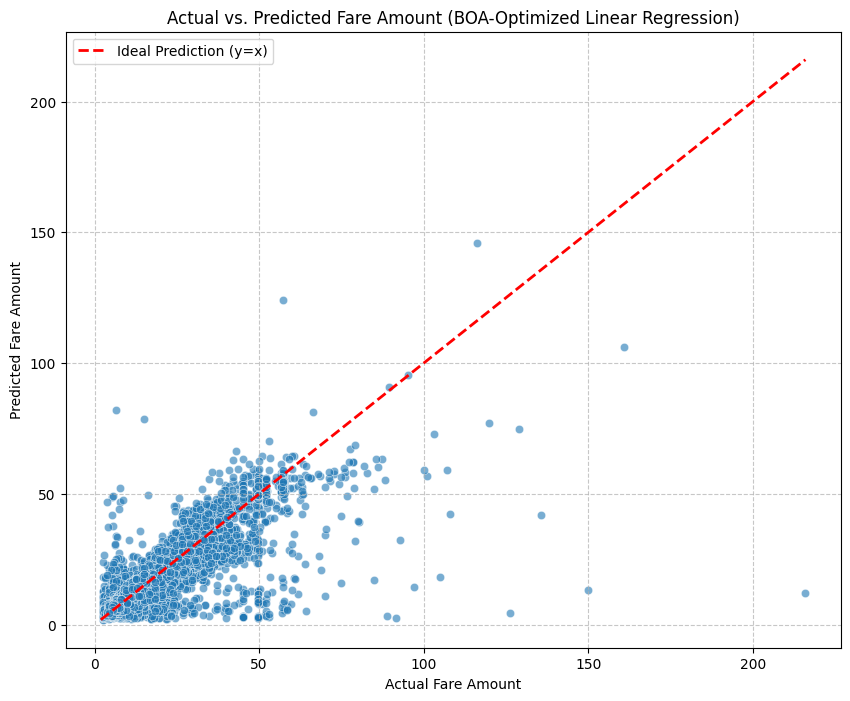

In [73]:
# Take a sample from the test data (X_test and y_test were defined earlier from df_train)
# Ensure X_test from the original train_test_split is used
# Note: loaded_boa_weights are the coefficients for the model, including the bias term.

# Add bias to the X_test data for prediction
X_test_biased_for_boa = add_bias(X_test.values)

# Make predictions using the loaded BOA-optimized weights
predictions_boa = X_test_biased_for_boa @ loaded_boa_weights

# Flatten the predictions array for easier plotting
predictions_boa_flat = predictions_boa.flatten()

# Create a DataFrame for easier plotting and comparison
comparison_df = pd.DataFrame({
    'Actual Fare Amount': y_test.values,
    'Predicted Fare Amount': predictions_boa_flat
})

# Display a few comparisons
print("Sample of Actual vs. Predicted Fare Amounts (BOA-optimized model):")
display(comparison_df.head())

# Visualization
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Actual Fare Amount', y='Predicted Fare Amount', data=comparison_df, alpha=0.6)

# Add a 45-degree line for ideal predictions
min_val = min(comparison_df['Actual Fare Amount'].min(), comparison_df['Predicted Fare Amount'].min())
max_val = max(comparison_df['Actual Fare Amount'].max(), comparison_df['Predicted Fare Amount'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction (y=x)')

plt.title('Actual vs. Predicted Fare Amount (BOA-Optimized Linear Regression)')
plt.xlabel('Actual Fare Amount')
plt.ylabel('Predicted Fare Amount')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## FOR KAGGLE

In [ ]:
# X_test_final = preprocess(df_test)
X_test_final = df_test
X_test_final = X_test_final[features]  # same order as df_train

In [ ]:
fast_model = W_final

X_test_bias = add_bias(X_test_final.values)
test_predictions = X_test_bias @ fast_model


In [ ]:
submission = pd.DataFrame({
    "key": df_test["key"],
    "fare_amount": test_predictions.flatten()
})

In [ ]:
submission.to_csv("submission.csv", index=False)

In [ ]:
# lr = LinearRegression()          # you can also add parameters like fit_intercept=False if needed
# lr.fit(X_train, y_train)

# # 3. Make predictions
# y_train_pred = lr.predict(X_train)
# y_test_pred  = lr.predict(X_test)

# # 4. Evaluate the model
# print("=== Linear Regression Results ===")
# print(f"Training R² : {r2_score(y_train, y_train_pred):.4f}")
# print(f"Test     R² : {r2_score(y_test,  y_test_pred):.4f}")
# print(f"Training RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
# print(f"Test     RMSE: {np.sqrt(mean_squared_error(y_test,  y_test_pred)):.4f}")
# print(f"Training MAE : {mean_absolute_error(y_train, y_train_pred):.4f}")
# print(f"Test     MAE : {mean_absolute_error(y_test,  y_test_pred):.4f}")

# # 5. Show coefficients and intercept
# print("\nCoefficients:")
# for feature, coef in zip(X.columns if hasattr(X, 'columns') else range(X.shape[1]), lr.coef_):
#     print(f"  {feature}: {coef:.4f}")
# print(f"Intercept: {lr.intercept_:.4f}")